# **데이터분석 및 전처리 실습**

<br>

## 학습목표

1. 데이터프레임(DataFrame) 생성, 내용확인, 조회하기 실습을 통하여 데이터프레임을 이해할수 있습니다. 
2. 데이터프레임(DataFrame)의 결측치를 찾고 결측치 제거와 대체를 할수 있습니다. 
3. 박스플랏그래프를 활용하여 이상치 파악후 이상치 삭제와 대체하는 방법을 실습하여 이상치 처리 방법을 이해할수 있습니다.
4. Feature Engineering 하는 방법에는 bining 구간화 실습을 하면서 Feature Engineering 개념을 이해할수 있습니다

<br>

<br>

# **Pandas 이해 및 활용 - DataFrame 살펴보기**

- 데이터프레임에 대해서 실습하는 시간을 갖도록 하겠습니다. 
- 정말로, 데이터 탐색과 데이터전처리시에 너무나도 많이 사용하는 데이터프레임에 대해서 확실히 이해하는 시간을 되도록 하겠습니다. 
- 데이터프레임을 잘 다룰수 있다면, 그만큼 편하게 데이터 탐색과 전처리를 수행할수 있으며 시간도 많이 줄일수 있습니다.
- 이챕터에서는 DataFrame 정의, DataFrame 생성, DataFrame 내용 확인, DataFrame 조회하기
- 그리고, DataFrame boolean indexing , DataFrame  추가, 삭제에 대해서 배워 보도록 하겠습니다. 

<br>

## __1. DataFrame이 뭔가요?__

>  - DataFrame은 2차원(col과 row을 가짐)테이블 데이터 구조를 가지는 자료형
>  - Data Analysis, Machine Learning에서 data 변형을 위해 가장 많이 사용
>  - **주의** : Series나 DataFrame은 대소문자가 구분되므로 Series, DataFrame으로 사용

In [1]:
# pandas import
import pandas as pd
import numpy as np

<br>

### <b>1-1. DataFrame 만들어 보기</b>

> Dictionary 형으로 생성 

In [2]:
a1 = pd.DataFrame({"a" : [1,2,3], "b" : [4,5,6], "c" : [7,8,9]})
a1

,a,b,c
0,1,4,7
1,2,5,8
2,3,6,9


>  List 형태로 데이터 프레임 생성

In [3]:
a2 = pd.DataFrame([[1,2,3], [4,5,6], [7,8,9]], ["a","b","c"])
a2

,0,1,2
a,1,2,3
b,4,5,6
c,7,8,9


<br>

### <b>1-2. 파일을 읽어서 DataFrame생성하기</b>
> - pandas.read_csv 함수 사용
>  - 대부분의 업무에서는 분석하고자 하는 Datat가 존재할 것
>  - 이를 읽어 들이는 것부터 데이터 분석의 시작!
>  - 이번 실습에서 읽을 파일 : sc_cust_info_txn_v1.5.csv

In [6]:
# sc_cust_info_txn_v1.5.csv 데이터 파일을 읽어오기
cust = pd.read_csv('./sc_cust_info_txn_v1.5.csv')

In [7]:
# 데이터프레임 변수 cust 확인하기
cust

,base_ym,dpro_tgt_perd_val,cust_ctg_type,cust_class,sex_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn
0,202006,20200630,10001,C,F,28,0,N,N,2640.0000,792.000000,1584.0000,0.0,0.0000,Y
1,202006,20200630,10001,_,_,_,1,N,N,300.0000,90.000000,180.0000,0.0,0.0000,Y
2,202006,20200630,10001,E,F,24,1,N,N,16840.0000,2526.000000,6983.0000,0.0,6981.0000,N
3,202006,20200630,10001,F,F,32,1,N,N,15544.7334,2331.710010,6750.4666,0.0,6508.8000,N
4,202006,20200630,10001,D,M,18,1,N,N,4700.0000,0.000000,4502.0000,0.0,4507.7000,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9925,202006,20200630,10001,C,F,15,1,N,Y,1296.0999,194.414985,643.1001,0.0,852.5499,N
9926,202006,20200630,10001,G,M,12,1,N,N,13799.6666,2069.949990,10605.9266,0.0,10603.9266,N
9927,202006,20200630,10005,C,_,_,1,N,N,1396.2000,1206.000000,0.0000,1212.0,0.0000,N
9928,202006,20200630,10001,C,F,40,0,N,N,3140.0000,942.000000,1884.0000,0.0,0.0000,Y


- DataFrame 데이터 살펴보기
>DataFrame의 구조 (인덱스, 컬럼, Values 구성)
 - 인덱스(Index) : 행의 레이블에 대한 정보
 - 컬럼(Columns) : 열의 레이블에 대한 정보
 - 값(Values) : 데이터 값

In [8]:
# 데이터프레임 변수 cust의 인덱스, 컬럼, Values 확인해 보기
cust

,base_ym,dpro_tgt_perd_val,cust_ctg_type,cust_class,sex_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn
0,202006,20200630,10001,C,F,28,0,N,N,2640.0000,792.000000,1584.0000,0.0,0.0000,Y
1,202006,20200630,10001,_,_,_,1,N,N,300.0000,90.000000,180.0000,0.0,0.0000,Y
2,202006,20200630,10001,E,F,24,1,N,N,16840.0000,2526.000000,6983.0000,0.0,6981.0000,N
3,202006,20200630,10001,F,F,32,1,N,N,15544.7334,2331.710010,6750.4666,0.0,6508.8000,N
4,202006,20200630,10001,D,M,18,1,N,N,4700.0000,0.000000,4502.0000,0.0,4507.7000,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9925,202006,20200630,10001,C,F,15,1,N,Y,1296.0999,194.414985,643.1001,0.0,852.5499,N
9926,202006,20200630,10001,G,M,12,1,N,N,13799.6666,2069.949990,10605.9266,0.0,10603.9266,N
9927,202006,20200630,10005,C,_,_,1,N,N,1396.2000,1206.000000,0.0000,1212.0,0.0000,N
9928,202006,20200630,10001,C,F,40,0,N,N,3140.0000,942.000000,1884.0000,0.0,0.0000,Y


<br>

### <b>1-3. 데이터 살펴보기</b>
- head, tail 함수사용하기
> - 데이터 전체가 아닌, 일부(처음부터, 혹은 마지막부터)를 간단히 보기 위한 함수 (default: 5줄)
 - **head, tail을 왜 사용할까?**
   - 광대한 데이터를 다룰 수 있는 Pandas의 특성상 특정변수에 제대로 데이터가 들어갔는지 간략히 확인
   - 데이터 자료형의 확인
   - 각 레이블에 맞는 데이터 매칭 확인

In [9]:
# 그냥 head 함수 실행해 보기 : 앞부분 5 라인 출력
cust.head()

,base_ym,dpro_tgt_perd_val,cust_ctg_type,cust_class,sex_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn
0,202006,20200630,10001,C,F,28,0,N,N,2640.0000,792.00000,1584.0000,0.0,0.0,Y
1,202006,20200630,10001,_,_,_,1,N,N,300.0000,90.00000,180.0000,0.0,0.0,Y
2,202006,20200630,10001,E,F,24,1,N,N,16840.0000,2526.00000,6983.0000,0.0,6981.0,N
3,202006,20200630,10001,F,F,32,1,N,N,15544.7334,2331.71001,6750.4666,0.0,6508.8,N
4,202006,20200630,10001,D,M,18,1,N,N,4700.0000,0.00000,4502.0000,0.0,4507.7,N


In [10]:
# 앞부분 3개 라인 출력
cust.head(n=3)

,base_ym,dpro_tgt_perd_val,cust_ctg_type,cust_class,sex_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn
0,202006,20200630,10001,C,F,28,0,N,N,2640.0,792.0,1584.0,0.0,0.0,Y
1,202006,20200630,10001,_,_,_,1,N,N,300.0,90.0,180.0,0.0,0.0,Y
2,202006,20200630,10001,E,F,24,1,N,N,16840.0,2526.0,6983.0,0.0,6981.0,N


In [11]:
#하위 5개 출력
cust.tail()

,base_ym,dpro_tgt_perd_val,cust_ctg_type,cust_class,sex_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn
9925,202006,20200630,10001,C,F,15,1,N,Y,1296.0999,194.414985,643.1001,0.0,852.5499,N
9926,202006,20200630,10001,G,M,12,1,N,N,13799.6666,2069.949990,10605.9266,0.0,10603.9266,N
9927,202006,20200630,10005,C,_,_,1,N,N,1396.2000,1206.000000,0.0000,1212.0,0.0000,N
9928,202006,20200630,10001,C,F,40,0,N,N,3140.0000,942.000000,1884.0000,0.0,0.0000,Y
9929,202006,20200630,10001,C,F,59,1,N,N,2436.9000,365.535000,1839.9000,0.0,1919.7999,N


In [12]:
#하위 3개 출력
cust.tail(n=3)

,base_ym,dpro_tgt_perd_val,cust_ctg_type,cust_class,sex_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn
9927,202006,20200630,10005,C,_,_,1,N,N,1396.2,1206.000,0.0,1212.0,0.0000,N
9928,202006,20200630,10001,C,F,40,0,N,N,3140.0,942.000,1884.0,0.0,0.0000,Y
9929,202006,20200630,10001,C,F,59,1,N,N,2436.9,365.535,1839.9,0.0,1919.7999,N


- DataFrame 기본 함수로 살펴보기
  - **shape :** 속성 반환값은 튜플로 존재하며 row과 col의 개수를 튜플로 반환함(row,col순)
  - columns : 해당 DataFrame을 구성하는 컬럼명을 확인할 수 있음
  - **info**  : 데이터 타입, 각 아이템의 개수 등 출력
  - describe : 데이터 컬럼별 요약 통계량을 나타냄, 숫자형 데이터의 통계치 계산
            (count:데이터의 갯수 / mean:평균값 / std:표준편차 / min:최소값 / 4분위 수 / max:최대값) 
  - dtypes : 데이터 형태의 종류(Data Types)

In [13]:
# shape : 데이터를 파악하는데 중요함
cust.shape

(9930, 15)

In [14]:
# DataFrame의 columns들을 보여줌
cust.columns

Index(['base_ym', 'dpro_tgt_perd_val', 'cust_ctg_type', 'cust_class',
       'sex_type', 'age', 'efct_svc_count', 'dt_stop_yn', 'npay_yn',
       'r3m_avg_bill_amt', 'r3m_A_avg_arpu_amt', 'r3m_B_avg_arpu_amt',
       'r6m_A_avg_arpu_amt', 'r6m_B_avg_arpu_amt', 'termination_yn'],
      dtype='object')

In [15]:
# DataFrame의 index들을 보여줌
cust.index

RangeIndex(start=0, stop=9930, step=1)

In [16]:
# DataFrame의 index들을 보여줌
cust.index.values

array([   0,    1,    2, ..., 9927, 9928, 9929], dtype=int64)

In [17]:
# DataFrame의 values들을 보여줌
cust.values

array([[202006, 20200630, 10001, ..., 0.0, 0.0, 'Y'],
       [202006, 20200630, 10001, ..., 0.0, 0.0, 'Y'],
       [202006, 20200630, 10001, ..., 0.0, 6981.0, 'N'],
       ...,
       [202006, 20200630, 10005, ..., 1212.0, 0.0, 'N'],
       [202006, 20200630, 10001, ..., 0.0, 0.0, 'Y'],
       [202006, 20200630, 10001, ..., 0.0, 1919.7999, 'N']], dtype=object)

In [18]:
# 데이터 타입 및 각 아이템등의 정보를 보여줌
cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9930 entries, 0 to 9929
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   base_ym             9930 non-null   int64  
 1   dpro_tgt_perd_val   9930 non-null   int64  
 2   cust_ctg_type       9930 non-null   int64  
 3   cust_class          9930 non-null   object 
 4   sex_type            9930 non-null   object 
 5   age                 9930 non-null   object 
 6   efct_svc_count      9930 non-null   int64  
 7   dt_stop_yn          9930 non-null   object 
 8   npay_yn             9930 non-null   object 
 9   r3m_avg_bill_amt    9930 non-null   float64
 10  r3m_A_avg_arpu_amt  9930 non-null   float64
 11  r3m_B_avg_arpu_amt  9930 non-null   float64
 12  r6m_A_avg_arpu_amt  9930 non-null   float64
 13  r6m_B_avg_arpu_amt  9930 non-null   float64
 14  termination_yn      9930 non-null   object 
dtypes: float64(5), int64(4), object(6)
memory usage: 1.1+ M

In [19]:
# DataFrame의 기본적인 통계정보를 보여줌
# 개수, 평균, 표준편차, 최소값, 1분위, 중간값, 3분위, 최대값 제공

cust.describe()

,base_ym,dpro_tgt_perd_val,cust_ctg_type,efct_svc_count,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt
count,9930.0,9930.0,9930.000000,9930.000000,9.930000e+03,9.930000e+03,9.930000e+03,9.930000e+03,9930.000000
mean,202006.0,20200630.0,10001.372810,1.520040,1.181774e+04,1.897536e+03,6.395259e+03,8.496206e+02,4624.897630
std,0.0,0.0,1.605016,15.404037,1.397822e+05,1.235342e+04,8.346138e+04,1.235124e+04,4561.049131
min,202006.0,20200630.0,10001.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,202006.0,20200630.0,10001.000000,1.000000,3.624503e+03,3.240000e+02,1.260000e+03,0.000000e+00,0.000000
50%,202006.0,20200630.0,10001.000000,1.000000,8.284467e+03,1.593307e+03,4.768617e+03,0.000000e+00,3959.316700
75%,202006.0,20200630.0,10001.000000,1.000000,1.372000e+04,2.308360e+03,7.982000e+03,1.006125e+03,7741.006900
max,202006.0,20200630.0,10010.000000,905.000000,1.281568e+07,1.188998e+06,7.689409e+06,1.208498e+06,64947.092000


In [20]:
# DataFrame의 데이터 종류
cust.dtypes

base_ym                 int64
dpro_tgt_perd_val       int64
cust_ctg_type           int64
cust_class             object
sex_type               object
age                    object
efct_svc_count          int64
dt_stop_yn             object
npay_yn                object
r3m_avg_bill_amt      float64
r3m_A_avg_arpu_amt    float64
r3m_B_avg_arpu_amt    float64
r6m_A_avg_arpu_amt    float64
r6m_B_avg_arpu_amt    float64
termination_yn         object
dtype: object

<br>

<br>

## __2. Data 조회하기__
DataFrame에서 data를 조회, 수정해보고 이를 이해해본다. 

<br>

### <b>1-1. 데이터 추출하기</b>

#### <b>1) 1개의 컬럼 선택하기</b>

In [21]:
# cust 데이터프레임에서 'cust_class' 컬럼을 조회할 경우 
cust['cust_class']

0       C
1       _
2       E
3       F
4       D
       ..
9925    C
9926    G
9927    C
9928    C
9929    C
Name: cust_class, Length: 9930, dtype: object

In [22]:
# 다른 방법으로 cust 데이터프레임에서 'cust_class' 컬럼을 조회할 경우 
cust.cust_class

0       C
1       _
2       E
3       F
4       D
       ..
9925    C
9926    G
9927    C
9928    C
9929    C
Name: cust_class, Length: 9930, dtype: object

#### <b>2) 복수의 컬럼 선택하기</b>

In [23]:
# 여러개의 요소들을 선택시 리스틀 사용하여 표시하면 된다.
# 'cust_class' , 'age' 'r3m_avg_bill_amt' 3개의 컬럼들을 리스트에 넣어 선택하면 된다. 

cust[ ['cust_class', 'age', 'r3m_avg_bill_amt'] ]

,cust_class,age,r3m_avg_bill_amt
0,C,28,2640.0000
1,_,_,300.0000
2,E,24,16840.0000
3,F,32,15544.7334
4,D,18,4700.0000
...,...,...,...
9925,C,15,1296.0999
9926,G,12,13799.6666
9927,C,_,1396.2000
9928,C,40,3140.0000


#### <b>3) DataFrame slicing</b>

>- 특정 **행 범위**를 가지고 오고 싶다면 [ ]를 사용
>- DataFrame의 경우 기본적으로 [ ] 연산자가 **column 선택**에 사용되지만 **slicing은 row 레벨**로 지원

In [24]:
# 7,8,9행을 가지고 옴 (인덱스 기준)
cust[ 7:10 ]

,base_ym,dpro_tgt_perd_val,cust_ctg_type,cust_class,sex_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn
7,202006,20200630,10001,D,F,65,1,N,N,4953.9334,987.0000,2700.3999,0.0000,2689.1,N
8,202006,20200630,10001,D,M,60,1,N,N,5503.0000,2093.0001,0.0000,1981.8999,0.0,N
9,202006,20200630,10001,C,F,67,1,N,N,1349.7000,1227.0000,0.0000,985.5000,0.0,N


In [25]:
# 그래서 1개의 인덱스로 접근시 컬럼명을 사용해야 에러가 안남
# 아래와 같이 인덱스를 base_ym 컬럼명으로 사용하면 됨. 
# 화면 결과는 인덱스와 값으로 구성된 Series 임.

cust[ 'base_ym' ] 

0       202006
1       202006
2       202006
3       202006
4       202006
         ...  
9925    202006
9926    202006
9927    202006
9928    202006
9929    202006
Name: base_ym, Length: 9930, dtype: int64

#### <b>4) row 선택하기</b>

 - DataFrame에서는 기본적으로 **[ ]을 사용하여 column을 선택**
 > __row 선택(두가지 방법이 존재)__
 > - **loc** : Dataframe에 존재하는 **인덱스를 그대로 사용** (인덱스 기준으로 행 데이터 읽기)
 > - **iloc** : Datafrmae에 존재하는 인덱스 상관없이 **0 based index로 사용** (행 번호 기준으로 행 데이터 읽기)
 > - 이 두 함수는 ,를 사용하여 column 선택도 가능
 > - 여기서 loc 함수를 실습 하겠습니다. 


In [26]:
cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9930 entries, 0 to 9929
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   base_ym             9930 non-null   int64  
 1   dpro_tgt_perd_val   9930 non-null   int64  
 2   cust_ctg_type       9930 non-null   int64  
 3   cust_class          9930 non-null   object 
 4   sex_type            9930 non-null   object 
 5   age                 9930 non-null   object 
 6   efct_svc_count      9930 non-null   int64  
 7   dt_stop_yn          9930 non-null   object 
 8   npay_yn             9930 non-null   object 
 9   r3m_avg_bill_amt    9930 non-null   float64
 10  r3m_A_avg_arpu_amt  9930 non-null   float64
 11  r3m_B_avg_arpu_amt  9930 non-null   float64
 12  r6m_A_avg_arpu_amt  9930 non-null   float64
 13  r6m_B_avg_arpu_amt  9930 non-null   float64
 14  termination_yn      9930 non-null   object 
dtypes: float64(5), int64(4), object(6)
memory usage: 1.1+ M

In [27]:
# cust 데이터프레임의 앞부분 확인 : 인덱스가 100부터 시작 확인
cust.head()

,base_ym,dpro_tgt_perd_val,cust_ctg_type,cust_class,sex_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn
0,202006,20200630,10001,C,F,28,0,N,N,2640.0000,792.00000,1584.0000,0.0,0.0,Y
1,202006,20200630,10001,_,_,_,1,N,N,300.0000,90.00000,180.0000,0.0,0.0,Y
2,202006,20200630,10001,E,F,24,1,N,N,16840.0000,2526.00000,6983.0000,0.0,6981.0,N
3,202006,20200630,10001,F,F,32,1,N,N,15544.7334,2331.71001,6750.4666,0.0,6508.8,N
4,202006,20200630,10001,D,M,18,1,N,N,4700.0000,0.00000,4502.0000,0.0,4507.7,N


In [28]:
# cust 데이터프레임의 뒤부분 확인 : 인덱스가 10029로 끝나는것 확인
cust.tail()

,base_ym,dpro_tgt_perd_val,cust_ctg_type,cust_class,sex_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn
9925,202006,20200630,10001,C,F,15,1,N,Y,1296.0999,194.414985,643.1001,0.0,852.5499,N
9926,202006,20200630,10001,G,M,12,1,N,N,13799.6666,2069.949990,10605.9266,0.0,10603.9266,N
9927,202006,20200630,10005,C,_,_,1,N,N,1396.2000,1206.000000,0.0000,1212.0,0.0000,N
9928,202006,20200630,10001,C,F,40,0,N,N,3140.0000,942.000000,1884.0000,0.0,0.0000,Y
9929,202006,20200630,10001,C,F,59,1,N,N,2436.9000,365.535000,1839.9000,0.0,1919.7999,N


In [29]:
# loc 함수를 이용해서 한개의 row만 가지고 오기 
# 아래 보이는 형식은 시리즈이며, 인덱스와 값으로 구성된다. 
cust.loc[ 9928 ]

base_ym                 202006
dpro_tgt_perd_val     20200630
cust_ctg_type            10001
cust_class                   C
sex_type                     F
age                         40
efct_svc_count               0
dt_stop_yn                   N
npay_yn                      N
r3m_avg_bill_amt        3140.0
r3m_A_avg_arpu_amt       942.0
r3m_B_avg_arpu_amt      1884.0
r6m_A_avg_arpu_amt         0.0
r6m_B_avg_arpu_amt         0.0
termination_yn               Y
Name: 9928, dtype: object

In [31]:
# 다시 loc 함수를 이용해서 한개의 row만 가지고 오기 
# 리스트에 인덱스 번호를 넣어 편하기 보자 : 1개 라인이지만, 화면에 보이는 형식은 데이터프레임이다.
cust.loc[ [ 9928 ] ]

,base_ym,dpro_tgt_perd_val,cust_ctg_type,cust_class,sex_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn
9928,202006,20200630,10001,C,F,40,0,N,N,3140.0,942.0,1884.0,0.0,0.0,Y


In [32]:
# 이번에는 여러개의 row 가져와 보기 
cust.loc[ [2, 102, 202] ]

,base_ym,dpro_tgt_perd_val,cust_ctg_type,cust_class,sex_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn
2,202006,20200630,10001,E,F,24,1,N,N,16840.00000,2526.0000,6983.0,0.0,6981.00,N
102,202006,20200630,10010,_,_,_,1,N,N,22362.93330,2082.0000,9410.0,0.0,9408.00,N
202,202006,20200630,10001,G,M,52,1,N,Y,17769.50989,1506.9999,14647.1,0.0,14744.95,N


- row, column 동시에 선택하기
 > loc 속성을 이용할 때, 콤마를 이용하여 row와 col 다 명시 가능

In [33]:
# loc 함수를 사용하여 cust 데이터프레임에서 102번째 인덱스의 'age' 컬럼의 값만 가져오기 
cust.loc[ 102, 'age' ]

'_'

In [35]:
# loc 함수를 사용하여 100, 200, 300 대상으로 cust_class, sex_type, age, r3m_avg_bill_amt, r3m_A_avg_arpu_amt  col 가지고 오기
# 여러개의 요소를 선택하려면 [] 리스트를 사용해야 함을 기억해 주세요.

cust.loc[ [100, 200, 300], ['cust_class', 'sex_type', 'age', 'r3m_avg_bill_amt'] ]   # row, col

,cust_class,sex_type,age,r3m_avg_bill_amt
100,E,M,61,9526.77000
200,D,M,84,11622.37472
300,_,M,60,3099.25011


#### __6) boolean indexing으로 row 선택하기__

 - 해당 조건에 맞는 row만 선택
 - 조건을 명시하고 조건을 명시한 형태로 inedxing 하여 가지고 옴
 - 2개 이상의 조건을 묶을때 AND나 OR을 사용할수 있으며, boolean indexing에서는 AND는 & 로, OR은 | 로 사용하오니 기억해 주시기 바랍니다.

 - ex: 남자이면서 3개월 평균 청구 금액이 50000 이상이면서 100000 미만인 사람만 가지고오기 

In [36]:
# 조건 : 남자이면서 3개월 평균 청구 금액이 50000 이상이면서 100000 미만인 사람만 가지고오기
# 조건 분해 
# 1. 남자
# 2. 개월 평균 청구 금액이 50000 이상이면서 100000 미만

In [37]:
# 첫번째 조건 : 남자 > 확인해 보자. 
# 먼저, 남녀 값을 가지고 있는 성별 'sex_type' 컬럼의 내용을 확인해 보자. 
cust['sex_type'].head()

0    F
1    _
2    F
3    F
4    M
Name: sex_type, dtype: object

In [38]:
# 성별 sex_type 컬럼의 값이 'M' 인 조건문 만들어 보자.
# 시리즈 형태로 보이며, 조건에 일치하면 True, 조건에 일치하지 않으면 False 구성되는것 확인

cust['sex_type'] == 'M'

0       False
1       False
2       False
3       False
4        True
        ...  
9925    False
9926     True
9927    False
9928    False
9929    False
Name: sex_type, Length: 9930, dtype: bool

In [42]:
# 그럼, 성별 sex_type 컬럼의 값이 'M' 남자인 데이터만 뽑아 보자.
# cust 데이터프레임에 조건문을 넣어주면 끝.
# 결과 출력을 보면 성별 sex_type 컬럼의 값이 'M' 남자만 있는것을 확인할수 있다.
# 이런식으로 조건을 사용하여 우리가 원하는 Raw들을 추출할수 있다. 

cust[  cust['sex_type'] == 'M'  ].head()

,base_ym,dpro_tgt_perd_val,cust_ctg_type,cust_class,sex_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn
4,202006,20200630,10001,D,M,18,1,N,N,4700.00000,0.0000,4502.0000,0.0000,4507.7000,N
6,202006,20200630,10001,D,M,22,1,N,N,13562.80000,2222.0001,3673.0000,0.0000,3671.0000,N
8,202006,20200630,10001,D,M,60,1,N,N,5503.00000,2093.0001,0.0000,1981.8999,0.0000,N
11,202006,20200630,10001,F,M,59,1,N,N,11472.33340,348.8001,8910.1334,0.0000,8908.0666,N
15,202006,20200630,10001,C,M,87,1,N,Y,2774.93326,2522.6666,0.0000,1233.9999,0.0000,N


In [43]:
# 위에서 우리가 찾을 조건 : "남자이면서 3개월 평균 청구 금액이 50000 이상이면서 100000 미만인 사람만" 가지고오기
# 조건1. 남자 
# 조건2. 3개월 평균 청구 금액이 50000 이상이면서 100000 미만
# 위에서 첫번째 조건 cust['sex_type']=='M' 확인했고 두번째 조건을 만들어 보자.
# 3개월 평균 청구 금액에 해당되는 컬럼명은 'r3m_avg_bill_amt' 이며 해당 컬럼을 가지고 조건문을 만들어 보자.
# 주의 사항은 조건문은 소괄호()로 묶어 주면 에러가 나지 않아, 되도록이면 소괄호로 묶어주는게 좋겠다. 
# 그리고, 3개월 평균 청구 금액이 50000 이상이면서 100000 미만이기에 중간의 & AND 논리연산자를 넣어 두개의 조건을 연결해 준다.
# 결과 출력을 보면 , 조건에 맞는것은  True 로 출력되고, 맞지 않는것은 False 로 출력된다.(시리즈 형태) 

( cust[ 'r3m_avg_bill_amt' ] >= 50000 ) & ( cust['r3m_avg_bill_amt'] < 100000 )

0       False
1       False
2       False
3       False
4       False
        ...  
9925    False
9926    False
9927    False
9928    False
9929    False
Name: r3m_avg_bill_amt, Length: 9930, dtype: bool

In [44]:
# 위에서 만든 남자 조건과 3개월 평균 청구 금액이 50000 이상이면서 100000 미만 조건을 cust 데이터프레임에 넣어주면 된다.

cust[ ( cust['sex_type']=='M' ) & ( cust['r3m_avg_bill_amt']>=50000 ) & ( cust['r3m_avg_bill_amt']< 100000 ) ]

,base_ym,dpro_tgt_perd_val,cust_ctg_type,cust_class,sex_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn
372,202006,20200630,10001,F,M,28,1,N,N,65113.66670,1310.400000,20083.5033,0.0000,19426.1983,N
1049,202006,20200630,10001,D,M,20,2,N,N,80335.67685,69136.100100,3896.3334,0.0000,3727.6666,N
1364,202006,20200630,10001,_,M,45,1,N,Y,54865.70000,2321.866600,8744.9382,0.0000,8774.7162,N
1793,202006,20200630,10001,G,M,48,1,N,N,64804.34037,47599.450100,11313.5866,0.0000,11351.4984,N
2027,202006,20200630,10001,G,M,47,1,N,Y,55368.98422,37432.266600,12903.1736,0.0000,12901.1736,N
2097,202006,20200630,10001,G,M,35,1,N,N,97205.00000,1820.799900,17491.6473,0.0000,12377.2057,N
2377,202006,20200630,10001,G,M,25,1,N,Y,68290.60000,1296.000000,40974.3600,0.0000,0.0000,Y
2392,202006,20200630,10001,G,M,23,1,N,Y,53565.53330,2751.000000,18515.6012,0.0000,17212.4013,N
2568,202006,20200630,10001,G,M,29,1,N,Y,68811.53330,2783.800000,8759.7534,0.0000,10098.9034,N
2604,202006,20200630,10001,G,M,43,1,N,Y,56557.13330,2041.599900,18895.0078,0.0000,14743.8312,N


In [45]:
# 조건문이 너무 길어지거나 복잡해지면...아래와 같은 방식으로 해도 무방함
# 남자이면서 
sex = ( cust['sex_type']=='M' )
# 3개월 평균 청구 금액이 50000 이상이면서 100000 미만
bill = (cust['r3m_avg_bill_amt']>=50000) & (cust['r3m_avg_bill_amt']< 100000)

cust[ sex & bill ].head(3)

,base_ym,dpro_tgt_perd_val,cust_ctg_type,cust_class,sex_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn
372,202006,20200630,10001,F,M,28,1,N,N,65113.66670,1310.4000,20083.5033,0.0,19426.1983,N
1049,202006,20200630,10001,D,M,20,2,N,N,80335.67685,69136.1001,3896.3334,0.0,3727.6666,N
1364,202006,20200630,10001,_,M,45,1,N,Y,54865.70000,2321.8666,8744.9382,0.0,8774.7162,N


<br>

<br>

### <b>1-2. 데이터 추가/삭제하기</b>

#### <b>1) 새 column 추가하기</b>

>- 데이터 전처리 과정에서 빈번하게 발생하는 것
>- insert 함수 사용하여 원하는 위치에 추가하기

In [46]:
# r3m_avg_bill_amt 두배로 새로운 col만들기
cust['r3m_avg_bill_amt2'] = cust['r3m_avg_bill_amt'] * 2
cust.head()

,base_ym,dpro_tgt_perd_val,cust_ctg_type,cust_class,sex_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn,r3m_avg_bill_amt2
0,202006,20200630,10001,C,F,28,0,N,N,2640.0000,792.00000,1584.0000,0.0,0.0,Y,5280.0000
1,202006,20200630,10001,_,_,_,1,N,N,300.0000,90.00000,180.0000,0.0,0.0,Y,600.0000
2,202006,20200630,10001,E,F,24,1,N,N,16840.0000,2526.00000,6983.0000,0.0,6981.0,N,33680.0000
3,202006,20200630,10001,F,F,32,1,N,N,15544.7334,2331.71001,6750.4666,0.0,6508.8,N,31089.4668
4,202006,20200630,10001,D,M,18,1,N,N,4700.0000,0.00000,4502.0000,0.0,4507.7,N,9400.0000


In [47]:
# 기존에 col을 연산하여 새로운 데이터 생성
cust['r3m_avg_bill_amt3'] = cust['r3m_avg_bill_amt2'] + cust['r3m_avg_bill_amt']
cust.head()

,base_ym,dpro_tgt_perd_val,cust_ctg_type,cust_class,sex_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn,r3m_avg_bill_amt2,r3m_avg_bill_amt3
0,202006,20200630,10001,C,F,28,0,N,N,2640.0000,792.00000,1584.0000,0.0,0.0,Y,5280.0000,7920.0000
1,202006,20200630,10001,_,_,_,1,N,N,300.0000,90.00000,180.0000,0.0,0.0,Y,600.0000,900.0000
2,202006,20200630,10001,E,F,24,1,N,N,16840.0000,2526.00000,6983.0000,0.0,6981.0,N,33680.0000,50520.0000
3,202006,20200630,10001,F,F,32,1,N,N,15544.7334,2331.71001,6750.4666,0.0,6508.8,N,31089.4668,46634.2002
4,202006,20200630,10001,D,M,18,1,N,N,4700.0000,0.00000,4502.0000,0.0,4507.7,N,9400.0000,14100.0000


#### __2) column 삭제하기__

>- drop 함수 사용하여 삭제
>- axis는 삭제를 가로(행)기준으로 할 것인지, 세로(열)기준으로 할 것인지 명시하는 'drop()'메소드의 파라미터임 
>- 리스트를 사용하면 멀티플 col 삭제 가능

In [48]:
# axis : dataframe은 차원이 존재 함으로 항상 0과 1이 존재 (0은 행레벨, 1을 열 레벨)
# drop 함수 수행시 화면에 출력되며, 해당 내용은 cust 데이터프레임에 저장된게 아니므로 주의하자.

cust.drop('r3m_avg_bill_amt3', axis=1)

,base_ym,dpro_tgt_perd_val,cust_ctg_type,cust_class,sex_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn,r3m_avg_bill_amt2
0,202006,20200630,10001,C,F,28,0,N,N,2640.0000,792.000000,1584.0000,0.0,0.0000,Y,5280.0000
1,202006,20200630,10001,_,_,_,1,N,N,300.0000,90.000000,180.0000,0.0,0.0000,Y,600.0000
2,202006,20200630,10001,E,F,24,1,N,N,16840.0000,2526.000000,6983.0000,0.0,6981.0000,N,33680.0000
3,202006,20200630,10001,F,F,32,1,N,N,15544.7334,2331.710010,6750.4666,0.0,6508.8000,N,31089.4668
4,202006,20200630,10001,D,M,18,1,N,N,4700.0000,0.000000,4502.0000,0.0,4507.7000,N,9400.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9925,202006,20200630,10001,C,F,15,1,N,Y,1296.0999,194.414985,643.1001,0.0,852.5499,N,2592.1998
9926,202006,20200630,10001,G,M,12,1,N,N,13799.6666,2069.949990,10605.9266,0.0,10603.9266,N,27599.3332
9927,202006,20200630,10005,C,_,_,1,N,N,1396.2000,1206.000000,0.0000,1212.0,0.0000,N,2792.4000
9928,202006,20200630,10001,C,F,40,0,N,N,3140.0000,942.000000,1884.0000,0.0,0.0000,Y,6280.0000


In [49]:
#원본 데이터를 열어 보면 원본 데이터는 안 지워진 상태
cust.head()

,base_ym,dpro_tgt_perd_val,cust_ctg_type,cust_class,sex_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn,r3m_avg_bill_amt2,r3m_avg_bill_amt3
0,202006,20200630,10001,C,F,28,0,N,N,2640.0000,792.00000,1584.0000,0.0,0.0,Y,5280.0000,7920.0000
1,202006,20200630,10001,_,_,_,1,N,N,300.0000,90.00000,180.0000,0.0,0.0,Y,600.0000,900.0000
2,202006,20200630,10001,E,F,24,1,N,N,16840.0000,2526.00000,6983.0000,0.0,6981.0,N,33680.0000,50520.0000
3,202006,20200630,10001,F,F,32,1,N,N,15544.7334,2331.71001,6750.4666,0.0,6508.8,N,31089.4668,46634.2002
4,202006,20200630,10001,D,M,18,1,N,N,4700.0000,0.00000,4502.0000,0.0,4507.7,N,9400.0000,14100.0000


In [50]:
# 원본 데이터를 지우고자 한다면... 
# 방법1 : 데이터를 지우고 다른 데이터 프레임에 저장
cust1 = cust.drop('r3m_avg_bill_amt3', axis=1)
cust1.head()

,base_ym,dpro_tgt_perd_val,cust_ctg_type,cust_class,sex_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn,r3m_avg_bill_amt2
0,202006,20200630,10001,C,F,28,0,N,N,2640.0000,792.00000,1584.0000,0.0,0.0,Y,5280.0000
1,202006,20200630,10001,_,_,_,1,N,N,300.0000,90.00000,180.0000,0.0,0.0,Y,600.0000
2,202006,20200630,10001,E,F,24,1,N,N,16840.0000,2526.00000,6983.0000,0.0,6981.0,N,33680.0000
3,202006,20200630,10001,F,F,32,1,N,N,15544.7334,2331.71001,6750.4666,0.0,6508.8,N,31089.4668
4,202006,20200630,10001,D,M,18,1,N,N,4700.0000,0.00000,4502.0000,0.0,4507.7,N,9400.0000


In [51]:
# 원본 자체를 지우고자 한다면...
# 방법 2 : inplace 파라미터를 할용 True인 경우 원본데이터에 수행
cust.drop('r3m_avg_bill_amt3', axis=1, inplace=True)

In [53]:
# 원본확인
cust.head(3)

,base_ym,dpro_tgt_perd_val,cust_ctg_type,cust_class,sex_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn,r3m_avg_bill_amt2
0,202006,20200630,10001,C,F,28,0,N,N,2640.0,792.0,1584.0,0.0,0.0,Y,5280.0
1,202006,20200630,10001,_,_,_,1,N,N,300.0,90.0,180.0,0.0,0.0,Y,600.0
2,202006,20200630,10001,E,F,24,1,N,N,16840.0,2526.0,6983.0,0.0,6981.0,N,33680.0


In [56]:
# 추가로 drop 함수를 이용해서 컬럼이 아니라 행을 삭제할수 있습니다.
# 이때 axis=0 을 사용하고 우리가 삭제하고자 하는 인덱스 번호를 주시면 됩니다.
# cust 데이터프레임에서 1, 2, 3 행을 삭제해 보겠습니다. 

cust.drop( [1, 2, 3] , axis=0 ).head()

,base_ym,dpro_tgt_perd_val,cust_ctg_type,cust_class,sex_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn,r3m_avg_bill_amt2
0,202006,20200630,10001,C,F,28,0,N,N,2640.0000,792.0000,1584.0000,0.0,0.0,Y,5280.0000
4,202006,20200630,10001,D,M,18,1,N,N,4700.0000,0.0000,4502.0000,0.0,4507.7,N,9400.0000
5,202006,20200630,10001,C,F,78,1,N,N,1361.7999,1173.9999,0.0000,1123.5,0.0,N,2723.5998
6,202006,20200630,10001,D,M,22,1,N,N,13562.8000,2222.0001,3673.0000,0.0,3671.0,N,27125.6000
7,202006,20200630,10001,D,F,65,1,N,N,4953.9334,987.0000,2700.3999,0.0,2689.1,N,9907.8668


<br>

<br>

# **[실습] 데이터프레임 살펴보기**

1. 아래 딕셔너리를 활용하여 df 데이터프레임을 만드세요.

<pre>
data = {
    '이름' : ['루피', '조로', '상디', '나미', '우솝', '쵸파', '로빈', '프랑키'],
    '고향' : ['Eastblue','Northblue','Northblue', 'Eastblue', 'Grandline', 'Grandline', 'OHARA', 'Waterseven'],
    '키' : [174, 181, 180, 170, 173, 90, 188, 240],
    '국어' : [90, 40, 80, 40, 15, 80, 55, 100],
    '영어' : [85, 35, 75, 60, 20, 100, 65, 85],
    '수학' : [100, 50, 70, 70, 10, 95, 45, 90],
    '과학' : [95, 55, 80, 75, 35, 85, 40, 95],
    '사회' : [85, 25, 75, 80, 10, 80, 35, 95],
    '기술' : ['레드호크', '아수라', '디아블잠브', '', '', '', '풀루르', '라디컬 빔']   
}

</pre>

In [57]:
# 아래 딕셔너리를 활용하여 df 데이터프레임을 만드세요.
# 먼저, 판다스 임포트하기

import pandas as pd

In [58]:
# 아래 딕셔너리를 활용하여 df 데이터프레임을 만들고 내용 조회하기

data = {
    '이름' : ['루피', '조로', '상디', '나미', '우솝', '쵸파', '로빈', '프랑키'],
    '고향' : ['Eastblue','Northblue','Northblue', 'Eastblue', 'Grandline', 'Grandline', 'OHARA', 'Waterseven'],
    '키' : [174, 181, 180, 170, 173, 90, 188, 240],
    '국어' : [90, 40, 80, 40, 15, 80, 55, 100],
    '영어' : [85, 35, 75, 60, 20, 100, 65, 85],
    '수학' : [100, 50, 70, 70, 10, 95, 45, 90],
    '과학' : [95, 55, 80, 75, 35, 85, 40, 95],
    '사회' : [85, 25, 75, 80, 10, 80, 35, 95],
    '기술' : ['레드호크', '아수라', '디아블잠브', '', '', '', '풀루르', '라디컬 빔']   
}

df = pd.DataFrame( data )   
df

,이름,고향,키,국어,영어,수학,과학,사회,기술
0,루피,Eastblue,174,90,85,100,95,85,레드호크
1,조로,Northblue,181,40,35,50,55,25,아수라
2,상디,Northblue,180,80,75,70,80,75,디아블잠브
3,나미,Eastblue,170,40,60,70,75,80,
4,우솝,Grandline,173,15,20,10,35,10,
5,쵸파,Grandline,90,80,100,95,85,80,
6,로빈,OHARA,188,55,65,45,40,35,풀루르
7,프랑키,Waterseven,240,100,85,90,95,95,라디컬 빔


In [ ]:
# df 데이터프레임의 앞쪽 5개 데이터 보기

df.head()

,이름,고향,키,국어,영어,수학,과학,사회,기술
0,루피,Eastblue,174,90,85,100,95,85,레드호크
1,조로,Northblue,181,40,35,50,55,25,아수라
2,상디,Northblue,180,80,75,70,80,75,디아블잠브
3,나미,Eastblue,170,40,60,70,75,80,
4,우솝,Grandline,173,15,20,10,35,10,


In [ ]:
# df 데이터프레임의 뒤쪽 5개 데이터 보기

df.tail()

,이름,고향,키,국어,영어,수학,과학,사회,기술
3,나미,Eastblue,170,40,60,70,75,80,
4,우솝,Grandline,173,15,20,10,35,10,
5,쵸파,Grandline,90,80,100,95,85,80,
6,로빈,OHARA,188,55,65,45,40,35,풀루르
7,프랑키,Waterseven,240,100,85,90,95,95,라디컬 빔


In [ ]:
# df 데이터프레임의 shape 정보 보기

df.shape

(8, 9)

In [ ]:
# df 데이터프레임의 index 보기

df.index
list(df.index)

[0, 1, 2, 3, 4, 5, 6, 7]

In [ ]:
# df 데이터프레임의 columns 보기

df.columns

Index(['이름', '고향', '키', '국어', '영어', '수학', '과학', '사회', '기술'], dtype='object')

In [ ]:
# df 데이터프레임의 columns에 대해서 마지막 2개의 컬럼만 뽑아 내기

df.columns[-2:]

Index(['사회', '기술'], dtype='object')

In [ ]:
# df 데이터프레임의 values 보기

df.values

array([['루피', 'Eastblue', 174, 90, 85, 100, 95, 85, '레드호크'],
       ['조로', 'Northblue', 181, 40, 35, 50, 55, 25, '아수라'],
       ['상디', 'Northblue', 180, 80, 75, 70, 80, 75, '디아블잠브'],
       ['나미', 'Eastblue', 170, 40, 60, 70, 75, 80, ''],
       ['우솝', 'Grandline', 173, 15, 20, 10, 35, 10, ''],
       ['쵸파', 'Grandline', 90, 80, 100, 95, 85, 80, ''],
       ['로빈', 'OHARA', 188, 55, 65, 45, 40, 35, '풀루르'],
       ['프랑키', 'Waterseven', 240, 100, 85, 90, 95, 95, '라디컬 빔']],
      dtype=object)

In [ ]:
# df 데이터프레임의 info 보기

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   이름      8 non-null      object
 1   고향      8 non-null      object
 2   키       8 non-null      int64 
 3   국어      8 non-null      int64 
 4   영어      8 non-null      int64 
 5   수학      8 non-null      int64 
 6   과학      8 non-null      int64 
 7   사회      8 non-null      int64 
 8   기술      8 non-null      object
dtypes: int64(6), object(3)
memory usage: 708.0+ bytes


In [ ]:
# df 데이터프레임의 통계정보 보기

df.describe()

,키,국어,영어,수학,과학,사회
count,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
mean,174.500000,62.500000,65.625000,66.250000,70.000000,60.625000
std,40.897083,29.519969,26.917533,30.325614,23.754699,32.120032
min,90.000000,15.000000,20.000000,10.000000,35.000000,10.000000
25%,172.250000,40.000000,53.750000,48.750000,51.250000,32.500000
50%,177.000000,67.500000,70.000000,70.000000,77.500000,77.500000
75%,182.750000,82.500000,85.000000,91.250000,87.500000,81.250000
max,240.000000,100.000000,100.000000,100.000000,95.000000,95.000000


In [ ]:
# df 데이터프레임에서 키컬럼과 영어컬럼만 보기

df[ [ '키' , '영어' ] ]

,키,영어
0,174,85
1,181,35
2,180,75
3,170,60
4,173,20
5,90,100
6,188,65
7,240,85


In [ ]:
# df 데이터프레임에서 5번 인덱스의 '국어' 컬럼의 값 확인하기

df.loc[ 5,  '국어' ]

80

In [ ]:
# df 데이터프레임 내용 다시 확인하기

df

,이름,고향,키,국어,영어,수학,과학,사회,기술
0,루피,Eastblue,174,90,85,100,95,85,레드호크
1,조로,Northblue,181,40,35,50,55,25,아수라
2,상디,Northblue,180,80,75,70,80,75,디아블잠브
3,나미,Eastblue,170,40,60,70,75,80,
4,우솝,Grandline,173,15,20,10,35,10,
5,쵸파,Grandline,90,80,100,95,85,80,
6,로빈,OHARA,188,55,65,45,40,35,풀루르
7,프랑키,Waterseven,240,100,85,90,95,95,라디컬 빔


In [ ]:
# boolean indexing을 활용해서 국어 점수가 80 이상인 데이터만 뽑아 보기
# 먼저, 국어점수 80 점 이상인 라인만 추출하기

df[ '국어' ] >= 80 

0     True
1    False
2     True
3    False
4    False
5     True
6    False
7     True
Name: 국어, dtype: bool

In [ ]:
# boolean indexing을 활용해서 국어 점수가 80 이상인 데이터만 뽑아 보기
# 국어점수 80 점 이상인 라인을 cond 저장하고 df 데이터프레임에서 조회하기

cond = ( df[ '국어' ] >= 80 )
df[ cond ] 

,이름,고향,키,국어,영어,수학,과학,사회,기술
0,루피,Eastblue,174,90,85,100,95,85,레드호크
2,상디,Northblue,180,80,75,70,80,75,디아블잠브
5,쵸파,Grandline,90,80,100,95,85,80,
7,프랑키,Waterseven,240,100,85,90,95,95,라디컬 빔


In [ ]:
# boolean indexing을 활용해서 국어 점수가 80 이상이고 수학 점수가 90 이상인 데이터만 뽑아 보기
# 국어점수 80 점 이상에 대한 boolean indexing  AND  수학점수 90 점 이상에 대한 boolean indexing

( df[ '국어' ] >= 80 ) & ( df[ '수학' ] >= 90 )

0     True
1    False
2    False
3    False
4    False
5     True
6    False
7     True
dtype: bool

In [ ]:
# boolean indexing을 활용해서 국어 점수가 80 이상이고 수학 점수가 90 이상인 데이터만 뽑아 보기
# 국어점수 80 점 이상에 대한 boolean indexing  AND  수학점수 90 점 이상에 대한 boolean indexing --> cond 저장
# cond를 df 데이터프레임에 넣어 조회하기

cond = ( df[ '국어' ] >= 80 ) & ( df[ '수학' ] >= 90 )
df[ cond ]

,이름,고향,키,국어,영어,수학,과학,사회,기술
0,루피,Eastblue,174,90,85,100,95,85,레드호크
5,쵸파,Grandline,90,80,100,95,85,80,
7,프랑키,Waterseven,240,100,85,90,95,95,라디컬 빔


In [ ]:
# 국어, 영어, 수학 3과목의 점수를 합쳐 '핵심과목' 컬럼에 저장하세요.

df[ '핵심과목' ] = df[ '국어' ] + df[ '영어' ] + df[ '수학' ]  
df

,이름,고향,키,국어,영어,수학,과학,사회,기술,핵심과목
0,루피,Eastblue,174,90,85,100,95,85,레드호크,275
1,조로,Northblue,181,40,35,50,55,25,아수라,125
2,상디,Northblue,180,80,75,70,80,75,디아블잠브,225
3,나미,Eastblue,170,40,60,70,75,80,,170
4,우솝,Grandline,173,15,20,10,35,10,,45
5,쵸파,Grandline,90,80,100,95,85,80,,275
6,로빈,OHARA,188,55,65,45,40,35,풀루르,165
7,프랑키,Waterseven,240,100,85,90,95,95,라디컬 빔,275


In [ ]:
# 국어, 영어, 수학 3과목의 점수을 합치고 평균을 구해  '핵심평균' 컬럼에 저장하세요.

df[ '핵심평균' ] = df[ '핵심과목' ] / 3
df

,이름,고향,키,국어,영어,수학,과학,사회,기술,핵심과목,핵심평균
0,루피,Eastblue,174,90,85,100,95,85,레드호크,275,91.666667
1,조로,Northblue,181,40,35,50,55,25,아수라,125,41.666667
2,상디,Northblue,180,80,75,70,80,75,디아블잠브,225,75.000000
3,나미,Eastblue,170,40,60,70,75,80,,170,56.666667
4,우솝,Grandline,173,15,20,10,35,10,,45,15.000000
5,쵸파,Grandline,90,80,100,95,85,80,,275,91.666667
6,로빈,OHARA,188,55,65,45,40,35,풀루르,165,55.000000
7,프랑키,Waterseven,240,100,85,90,95,95,라디컬 빔,275,91.666667


In [ ]:
# 이름 컬럼을 삭제하세요. 

df.drop( '이름', axis=1 )

,고향,키,국어,영어,수학,과학,사회,기술,핵심과목,핵심평균
0,Eastblue,174,90,85,100,95,85,레드호크,275,91.666667
1,Northblue,181,40,35,50,55,25,아수라,125,41.666667
2,Northblue,180,80,75,70,80,75,디아블잠브,225,75.000000
3,Eastblue,170,40,60,70,75,80,,170,56.666667
4,Grandline,173,15,20,10,35,10,,45,15.000000
5,Grandline,90,80,100,95,85,80,,275,91.666667
6,OHARA,188,55,65,45,40,35,풀루르,165,55.000000
7,Waterseven,240,100,85,90,95,95,라디컬 빔,275,91.666667


<br>

<br>

# **데이터 전처리 - 데이터탐색, 결측치처리**

- 데이터 분석/AI 모델링을 위하여 데이터를 정제하는 전처리 과정은 아래와 같습니다.
    - 첫번째, 데이터 탐색하기
    - 두번째, 결측치 처리하기
    - 세번째, 이상치 처리하기
    - 네번째, Feature Engineering 
- 전처리 과정 순서대로 실습을 통해 배워 보도록 하겠습니다.
- 먼저, 데이터 탐색과 결측치 처리하기 부터 실습해 보도록 하겠습니다.

<br>

## **0. 필요 라이브러리와 데이터 불러오기**

In [ ]:
# 필요한 라이브러리 불러오기
import pandas as pd
import numpy as np

# warning 경고 제거하기
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 판다스 옵션을 사용해서 화면에 보기 좋기 보이게 하기

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option("display.max_columns", 999)

In [ ]:
# sc_cust_info_txn_v1.5.csv 데이터 파일을 읽고 df 데이터프레임에 저장합니다.

df = pd.read_csv("sc_cust_info_txn_v1.5.csv")

In [ ]:
# 저장된 df 데이터프레임 확인하기
df.tail(3)

,base_ym,dpro_tgt_perd_val,cust_ctg_type,cust_class,sex_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn
9927,202006,20200630,10005,C,_,_,1,N,N,1396.20,1206.00,0.00,1212.00,0.00,N
9928,202006,20200630,10001,C,F,40,0,N,N,3140.00,942.00,1884.00,0.00,0.00,Y
9929,202006,20200630,10001,C,F,59,1,N,N,2436.90,365.54,1839.90,0.00,1919.80,N


<br>

## **1. 데이터 탐색하기**

### **데이터 확인하기**
Dataframe에서 제공하는 메소드를 활용하여 데이터의 구성을 확인합니다.    
info는 데이터 구성과 특성을 확인해 볼 수 있습니다

In [ ]:
# 데이터프레임의 구성과 특성을 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9930 entries, 0 to 9929
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   base_ym             9930 non-null   int64  
 1   dpro_tgt_perd_val   9930 non-null   int64  
 2   cust_ctg_type       9930 non-null   int64  
 3   cust_class          9930 non-null   object 
 4   sex_type            9930 non-null   object 
 5   age                 9930 non-null   object 
 6   efct_svc_count      9930 non-null   int64  
 7   dt_stop_yn          9930 non-null   object 
 8   npay_yn             9930 non-null   object 
 9   r3m_avg_bill_amt    9930 non-null   float64
 10  r3m_A_avg_arpu_amt  9930 non-null   float64
 11  r3m_B_avg_arpu_amt  9930 non-null   float64
 12  r6m_A_avg_arpu_amt  9930 non-null   float64
 13  r6m_B_avg_arpu_amt  9930 non-null   float64
 14  termination_yn      9930 non-null   object 
dtypes: float64(5), int64(4), object(6)
memory usage: 1.1+ M

In [ ]:
# df 데이터프레임의 앞 5개 라인 확인하기
df.head()

,base_ym,dpro_tgt_perd_val,cust_ctg_type,cust_class,sex_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn
0,202006,20200630,10001,C,F,28,0,N,N,2640.00,792.00,1584.00,0.00,0.00,Y
1,202006,20200630,10001,_,_,_,1,N,N,300.00,90.00,180.00,0.00,0.00,Y
2,202006,20200630,10001,E,F,24,1,N,N,16840.00,2526.00,6983.00,0.00,6981.00,N
3,202006,20200630,10001,F,F,32,1,N,N,15544.73,2331.71,6750.47,0.00,6508.80,N
4,202006,20200630,10001,D,M,18,1,N,N,4700.00,0.00,4502.00,0.00,4507.70,N


In [ ]:
# df 데이터프레임의 뒤 5개 라인 확인하기
df.tail()

,base_ym,dpro_tgt_perd_val,cust_ctg_type,cust_class,sex_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt,termination_yn
9925,202006,20200630,10001,C,F,15,1,N,Y,1296.10,194.41,643.10,0.00,852.55,N
9926,202006,20200630,10001,G,M,12,1,N,N,13799.67,2069.95,10605.93,0.00,10603.93,N
9927,202006,20200630,10005,C,_,_,1,N,N,1396.20,1206.00,0.00,1212.00,0.00,N
9928,202006,20200630,10001,C,F,40,0,N,N,3140.00,942.00,1884.00,0.00,0.00,Y
9929,202006,20200630,10001,C,F,59,1,N,N,2436.90,365.54,1839.90,0.00,1919.80,N


In [ ]:
# df 데이터프레임에 대해서 기술적 통계 확인합니다. 
# 연속형 컬럼에 대해서 평균, 표준편차, 최소값, 최대값등을 출력합니다.

df.describe()

,base_ym,dpro_tgt_perd_val,cust_ctg_type,efct_svc_count,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,r6m_A_avg_arpu_amt,r6m_B_avg_arpu_amt
count,9930.00,9930.00,9930.00,9930.00,9930.00,9930.00,9930.00,9930.00,9930.00
mean,202006.00,20200630.00,10001.37,1.52,11817.74,1897.54,6395.26,849.62,4624.90
std,0.00,0.00,1.61,15.40,139782.18,12353.42,83461.38,12351.24,4561.05
min,202006.00,20200630.00,10001.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,202006.00,20200630.00,10001.00,1.00,3624.50,324.00,1260.00,0.00,0.00
50%,202006.00,20200630.00,10001.00,1.00,8284.47,1593.31,4768.62,0.00,3959.32
75%,202006.00,20200630.00,10001.00,1.00,13720.00,2308.36,7982.00,1006.12,7741.01
max,202006.00,20200630.00,10010.00,905.00,12815682.13,1188998.30,7689409.28,1208497.66,64947.09


### <b>필요한 컬럼만 추출하기</b>
수집한 데이터의 컬럼이 너무 많을 경우 데이터 처리에 불필요한 시간과 자원이 계속 소모 되기에,     
이번 수업에서는 필요한 컬럼만 추출하여 데이터처리를 하도록 하겠습니다.    
실제 분석/모델링에서는 어떤 컬럼이 중요할지 알수 없기 떄문에 자원이 가능한 많은 데이터를 가지고 하셔도 좋습니다. 

In [ ]:
# 데이터 처리에 필요한 10개 항목만 추출하겠습니다. 
# 고객등급(cust_class), 성별(sex_type), 나이(age), 사용서비스수(efct_svc_count), 서비스중지여부 (dt_stop_yn), 미납여부(npay_yn)
# 3개월 평균 요금(r3m_avg_bill_amt), A서비스 3개월 평균요금(r3m_A_avg_arpu_amt), B서비스 3개월 평균요금(r3m_B_avg_arpu_amt), 해지여부(termination_yn)
# 10개의 필요한 컬럼들을 리스트에 넣으면 되고, 결과를 cust 데이터프레임에 저장합니다. 

cust = df[ ["cust_class","sex_type","age","efct_svc_count","dt_stop_yn",
         "npay_yn","r3m_avg_bill_amt","r3m_A_avg_arpu_amt","r3m_B_avg_arpu_amt", "termination_yn"] ]

In [ ]:
# cust 데이터프레임의 앞 5개 데이터 확인
# 10개 컬럼으로 구성되었고 전보다 보기 좋아 보이네요.

cust.head()

,cust_class,sex_type,age,efct_svc_count,dt_stop_yn,npay_yn,r3m_avg_bill_amt,r3m_A_avg_arpu_amt,r3m_B_avg_arpu_amt,termination_yn
0,C,F,28,0,N,N,2640.00,792.00,1584.00,Y
1,_,_,_,1,N,N,300.00,90.00,180.00,Y
2,E,F,24,1,N,N,16840.00,2526.00,6983.00,N
3,F,F,32,1,N,N,15544.73,2331.71,6750.47,N
4,D,M,18,1,N,N,4700.00,0.00,4502.00,N


실습의 편의를 위해 컬럼명을 조금 더 간결하고 직관적으로 변경해 보겠습니다.     
실제 여러명이 동시에 진행하는 분석 프로젝트나 모델링에서는 정해진 네이밍 룰에 따라 변경하거나 원천 컬럼명을 그대로 사용하는 것이 좋습니다. 

In [ ]:
# 컬럼명을 간결하고 직관적으로 변경해 보겠습니다. 
# rename 함수를 사용하여 컬럼명 변경합니다. 

cust = cust.rename( columns = {"cust_class" : 'class',          # 고객등급
                             "sex_type":'sex',                # 성별
                             "efct_svc_count":'service',      # 사용 서비스수
                             "dt_stop_yn":'stop',             # 서비스 중지 여부
                             "npay_yn":'npay',                # 미납 여부
                             "r3m_avg_bill_amt":'avg_bill',   # 3개월 평균 요금
                             "r3m_A_avg_arpu_amt":"A_bill",   # A서비스 3개월 평균요금
                             "r3m_B_avg_arpu_amt":'B_bill',   # B서비스 3개월 평균요금
                             "termination_yn":'termination' } # 해지 여부
                ) 

In [ ]:
# cust 데이터프레임의 이름 변경 확인하기
# 컬럼이름이 간결해져서 보기 좋네요.

cust.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28,0,N,N,2640.00,792.00,1584.00,Y
1,_,_,_,1,N,N,300.00,90.00,180.00,Y
2,E,F,24,1,N,N,16840.00,2526.00,6983.00,N
3,F,F,32,1,N,N,15544.73,2331.71,6750.47,N
4,D,M,18,1,N,N,4700.00,0.00,4502.00,N


In [ ]:
# cust 데이터프레임의 기술적 통계정보 보기
# avg_bill, A_bill, B_bill 컬럼의 max 값이 굉장히 큰것을 알수 있습니다.

cust.describe()

,service,avg_bill,A_bill,B_bill
count,9930.00,9930.00,9930.00,9930.00
mean,1.52,11817.74,1897.54,6395.26
std,15.40,139782.18,12353.42,83461.38
min,0.00,0.00,0.00,0.00
25%,1.00,3624.50,324.00,1260.00
50%,1.00,8284.47,1593.31,4768.62
75%,1.00,13720.00,2308.36,7982.00
max,905.00,12815682.13,1188998.30,7689409.28


<br>

### <b>데이터 타입 변경하기</b>
데이터를 불러온 후에는 반드시 데이터 타입을 확인해 주시는것이 좋습니다.    
숫자형 데이터가 문자형으로 지정되어 있거나 혹은 그반대의 경우 원하는 데이터 처리 결과가 도출 되지 않을 수 있습니다.

In [ ]:
# cust 데이터프레임의 구성과 정보에 대해 확인해 보겠습니다.
# 10개의 컬럼으로 구성되었으며, 컬럼 이름이 간결해 진걸 확인할수 있습니다.
# 그런데, age 컬럼의 타입이 숫자형이 아니라  object 문자열로 나오고 있습니다.

cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9930 entries, 0 to 9929
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   class        9930 non-null   object 
 1   sex          9930 non-null   object 
 2   age          9930 non-null   object 
 3   service      9930 non-null   int64  
 4   stop         9930 non-null   object 
 5   npay         9930 non-null   object 
 6   avg_bill     9930 non-null   float64
 7   A_bill       9930 non-null   float64
 8   B_bill       9930 non-null   float64
 9   termination  9930 non-null   object 
dtypes: float64(3), int64(1), object(6)
memory usage: 775.9+ KB


In [ ]:
# 실제 age 컬럼의 값들을 확인해 보겠습니다.
# age 컬럼의 값들을 보니 '_'가 있네요. 
# 그래서 판다스에서 age 컬럼을 숫자로 보지 않고 문자열 object로 파악했네요

cust[ 'age' ].head()

0    28
1     _
2    24
3    32
4    18
Name: age, dtype: object

In [ ]:
# astype() 함수를 활용허여 age 컬럼의 타입을 숫자형으로 변경해 보겠습니다. 
# 강제로 숫자 타입을 변경하려고 했는데, 에러가 발생합니다. 
# 왜냐하면, '_' 글자를 숫자 0~9 중에 어떤걸로 변경할수가 없으니 에러가 당근 발생합니다. 

cust[ 'age' ].astype( 'int' )

ValueError: invalid literal for int() with base 10: '_'

In [ ]:
# age 컬럼의 '_' 값을 뭐로 바꿔야 할지 모르니
# 문제 해결을 위해 replace 함수를 활용해서 age 컬럼의 '_' 문자값을 NaN 값으로 치환해 보겠습니다. 
# 치환된 결과를 다시 cust 데이터프레임에 저장 합니다. 

cust = cust.replace("_", np.NaN)

In [ ]:
# 잘 처리되었는지 확인 위해서 age 컬럼의 내용을 보겠습니다. 
# 결과를 보니 기존의 '_' 문자열이 NaN null로 변경됨을 확인할수 있습니다. 잘 치환되었네요.

cust[ 'age' ].head()

0     28
1    NaN
2     24
3     32
4     18
Name: age, dtype: object

In [ ]:
# 다시 cust 데이터프레임의 구성과 정보에 대해 확인해 보겠습니다.
# 아직도, age 컬럼의 타입이 object 문자열로 나오고 있네요.

cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9930 entries, 0 to 9929
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   class        8529 non-null   object 
 1   sex          9249 non-null   object 
 2   age          9178 non-null   object 
 3   service      9930 non-null   int64  
 4   stop         9930 non-null   object 
 5   npay         9930 non-null   object 
 6   avg_bill     9930 non-null   float64
 7   A_bill       9930 non-null   float64
 8   B_bill       9930 non-null   float64
 9   termination  9930 non-null   object 
dtypes: float64(3), int64(1), object(6)
memory usage: 775.9+ KB


In [ ]:
# 다시, astype 함수를 활용해서 age 컬럼의 타입을 숫자형으로 변경해 보겠습니다. 
# NaN의 경우 int type을 지원하지 않아 float type으로 변경합니다. 

cust[ 'age' ] = cust[ 'age' ].astype('float')

In [ ]:
# astype 실행 결과를 확인해 보겠습니다.
# age 컬럼 타입이 float 변경됨을 확인할수 있습니다.

cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9930 entries, 0 to 9929
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   class        8529 non-null   object 
 1   sex          9249 non-null   object 
 2   age          9178 non-null   float64
 3   service      9930 non-null   int64  
 4   stop         9930 non-null   object 
 5   npay         9930 non-null   object 
 6   avg_bill     9930 non-null   float64
 7   A_bill       9930 non-null   float64
 8   B_bill       9930 non-null   float64
 9   termination  9930 non-null   object 
dtypes: float64(4), int64(1), object(5)
memory usage: 775.9+ KB


In [ ]:
# cust 데이터프레임의 age 컬럼의 값들도 확인해 보겠습니다. 
# age 컬럼의 값들이 실수형(float)로 나오고 있음을 확인할수 있네요.

cust.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.00,0,N,N,2640.00,792.00,1584.00,Y
1,NaN,NaN,NaN,1,N,N,300.00,90.00,180.00,Y
2,E,F,24.00,1,N,N,16840.00,2526.00,6983.00,N
3,F,F,32.00,1,N,N,15544.73,2331.71,6750.47,N
4,D,M,18.00,1,N,N,4700.00,0.00,4502.00,N


In [ ]:
# 이번에는 loc 함수를 사용해서 원하는 행과 컬럼을 접근해 보겠습니다. 
# cust 데이터프레임의 첫번째 행 접근하기 : 시리즈 형태로 보입니다. 

cust.loc[ 0 ]

class               C
sex                 F
age             28.00
service             0
stop                N
npay                N
avg_bill      2640.00
A_bill         792.00
B_bill        1584.00
termination         Y
Name: 0, dtype: object

In [ ]:
# 이번에는 loc 함수를 사용해서 원하는 행과 컬럼을 접근해 보겠습니다. 
# cust 데이터프레임의 [1 ,3, 5] 인덱스 접근하기 : 1, 3,,5 인덱스의 행라인을 볼수 있습니다. 

cust.loc[ [ 1, 3, 5 ] ]

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
1,NaN,NaN,NaN,1,N,N,300.00,90.00,180.00,Y
3,F,F,32.00,1,N,N,15544.73,2331.71,6750.47,N
5,C,F,78.00,1,N,N,1361.80,1174.00,0.00,N


In [ ]:
# 이번에는 loc 함수를 사용해서 원하는 행과 컬럼을 접근해 보겠습니다. 
# cust 데이터프레임의 [1 ,3, 5] 인덱스의 class 컬럼만 확인해 보겠습니다. : 시리즈 형태로 보입니다. 

cust.loc[ [ 1, 3, 5 ] , 'class' ]

1    NaN
3      F
5      C
Name: class, dtype: object

In [ ]:
# 이번에는 loc 함수를 사용해서 원하는 행과 컬럼을 접근해 보겠습니다. 
# cust 데이터프레임의 [1 ,3, 5] 인덱스의 class 컬럼,service 컬럼, avg_bill컬럼을 접근해 보겠습니다.
# loc 함수를 많이 사용하오니, 반드시 익혀서 잘 사용하시길 바랍니다.

cust.loc[ [ 1, 3, 5 ] , [ 'class',  'service',  'avg_bill' ] ]

,class,service,avg_bill
1,NaN,1,300.00
3,F,1,15544.73
5,C,1,1361.80


<br>

## **2. 결측치 처리하기**
- 결측치 : Missing Value로 데이터에 값이 없는 것을 의미. NA, Null, NaN으로 표시

### <span style="color:RED">[참고]</span> 데이터 변경시 되도록 원본 데이터를 COPY 해서 사용할것!!
파이썬에서 Copy 메소드를 사용하지 않으면 주소값을 복사해서 사용기 때문에 원본 값을 변경 시키게 됩니다.    
따라서 원본 항목을 보전하면서 데이터를 보정하려면 copy 메소드를 사용 해주시기 바랍니다.

In [ ]:
# copy() 함수를 이용해서 기존 Cust 데이터프레임을 새로운 cust_fix 데이터프레임으로 복사하기 
cust_fix = cust.copy()

In [ ]:
# 새로 만든 cust_fix 데이터프레임 확인하기
cust_fix.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.00,0,N,N,2640.00,792.00,1584.00,Y
1,NaN,NaN,NaN,1,N,N,300.00,90.00,180.00,Y
2,E,F,24.00,1,N,N,16840.00,2526.00,6983.00,N
3,F,F,32.00,1,N,N,15544.73,2331.71,6750.47,N
4,D,M,18.00,1,N,N,4700.00,0.00,4502.00,N


<br>

### <b>결측치 채우기 </b>

사용자가 지정하는 단일값으로 채워서 결측치를 처리하는 방법입니다.

In [ ]:
# 결측치 채우기 이전에 먼저, cust 데이터프레임에 NaN null 결측치가 있는지 확인해 봅니다.
# 확인해 보니, 1번 인덱스에 Class 컬럼, sex컬럼, age 컬럼에 NaN null 결측치가 보이네요.

cust.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.00,0,N,N,2640.00,792.00,1584.00,Y
1,NaN,NaN,NaN,1,N,N,300.00,90.00,180.00,Y
2,E,F,24.00,1,N,N,16840.00,2526.00,6983.00,N
3,F,F,32.00,1,N,N,15544.73,2331.71,6750.47,N
4,D,M,18.00,1,N,N,4700.00,0.00,4502.00,N


In [ ]:
# 위와 같이 cust 데이터프레임 데이터를 조회해서 NaN null 있음을 육안으로 확인할수도 있고
# info() 함수를 사용해서 확인할수도 있습니다.
# info() 함수의 결과를 보니, 총라인건수가 9,930건인데 
# class 컬럼, sex컬럼, age컬럼에 NaN null 존재하여 각각 8,529건, 9,249건, 9,178건으로 9,930건이 
# 안되는것을 확인할수 있습니다.

cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9930 entries, 0 to 9929
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   class        8529 non-null   object 
 1   sex          9249 non-null   object 
 2   age          9178 non-null   float64
 3   service      9930 non-null   int64  
 4   stop         9930 non-null   object 
 5   npay         9930 non-null   object 
 6   avg_bill     9930 non-null   float64
 7   A_bill       9930 non-null   float64
 8   B_bill       9930 non-null   float64
 9   termination  9930 non-null   object 
dtypes: float64(4), int64(1), object(5)
memory usage: 775.9+ KB


In [ ]:
# 결측치 확인할수 있는 다른 방법은 isnull() 함수를 통해서 NaN null 확인 할수 있습니다.
# 각 value 값들이 null 이냐?고 물어 보는겁니다. 
# null이 맞으면 True, null이 아니면 False로 표현합니다. 

cust.isnull().head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,False,False,False,False,False,False,False,False,False,False
1,True,True,True,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False


In [ ]:
# isnull() 함수로 사용하니, 각 value 값들이 null 인지 , 아닌지 알수 있지만,
# 한눈에 안들어오므로, sum() 함수를 추가로 사용해서 컬럼별로 null 총합을 보도록 하겠습니다.
# class 컬럼에 1,401건의 null 값이 존재하고, sex 컬럼엔 681건, age 컬럼엔 752건의 null이 존재함을 알수 있습니다.

cust.isnull().sum()

class          1401
sex             681
age             752
service           0
stop              0
npay              0
avg_bill          0
A_bill            0
B_bill            0
termination       0
dtype: int64

In [ ]:
# fillna 함수를 사용해서 cust 데이터프레임 전체에 대해서 
# NaN null값을 숫자 15로 변경해 보겠습니다. 
# 여기서는 테스트이므로 임의의 값으로 변경하지만, 
# 실무에서는 일괄적으로 변경시 데이터의 편향이 틀어질수 있음에 유의해 주시기 바랍니다. 

cust = cust.fillna(15)

In [ ]:
# 결측치를 숫자 15로 변경후 cust 데이터프레임을 확인해 보니
# 1번 인덱스에 존재하는 NaN도 15번 변경된것을 확인할수 있습니다.

cust.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.00,0,N,N,2640.00,792.00,1584.00,Y
1,15,15,15.00,1,N,N,300.00,90.00,180.00,Y
2,E,F,24.00,1,N,N,16840.00,2526.00,6983.00,N
3,F,F,32.00,1,N,N,15544.73,2331.71,6750.47,N
4,D,M,18.00,1,N,N,4700.00,0.00,4502.00,N


In [ ]:
# 앞에서 info 함수를 통해 확인해 보니, 
# 모든 컬럼의 라인개수가 9930건으로  결측치가 1개도 없음을 알수 있습니다.

cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9930 entries, 0 to 9929
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   class        9930 non-null   object 
 1   sex          9930 non-null   object 
 2   age          9930 non-null   float64
 3   service      9930 non-null   int64  
 4   stop         9930 non-null   object 
 5   npay         9930 non-null   object 
 6   avg_bill     9930 non-null   float64
 7   A_bill       9930 non-null   float64
 8   B_bill       9930 non-null   float64
 9   termination  9930 non-null   object 
dtypes: float64(4), int64(1), object(5)
memory usage: 775.9+ KB


In [ ]:
# 다시 isnull() 함수를 사용해서 컬럼별 null 총합을 확인해 보겠습니다. 
# 모든 컬럼에는 null 갯수가 0으로 나와 null 없음을 확인할수 있습니다. 

cust.isnull().sum()

class          0
sex            0
age            0
service        0
stop           0
npay           0
avg_bill       0
A_bill         0
B_bill         0
termination    0
dtype: int64

### <b>결측치 제거하기</b>
결측치를 채우기로 처리하다보면 경우에 따라 값의 왜곡이 발생하는 경우가 있습니다.    
이때는 제거하기 기법을 사용하여 결측치를 처리하면 데이터의 정합성을 보존 할 수 있습니다.

In [ ]:
# 결측치 실습을 위해 copy() 함수로 복사하겠습니다.
cust = cust_fix.copy()

In [ ]:
# 결측치 제거하기 실습을 하기전에 , 다시 info 함수로 cust 데이터프레임 구성 보겠습니다.
# 전체 라인은 9930 개이고, class, sex, age 컬럼에 결측지 존재함을 알수 있습니다.

cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9930 entries, 0 to 9929
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   class        8529 non-null   object 
 1   sex          9249 non-null   object 
 2   age          9178 non-null   float64
 3   service      9930 non-null   int64  
 4   stop         9930 non-null   object 
 5   npay         9930 non-null   object 
 6   avg_bill     9930 non-null   float64
 7   A_bill       9930 non-null   float64
 8   B_bill       9930 non-null   float64
 9   termination  9930 non-null   object 
dtypes: float64(4), int64(1), object(5)
memory usage: 775.9+ KB


In [ ]:
# listwise 방식 : 1개의 NaN이 존재하면 제거 하기
# dropna() 함수를 이용해서 1개의 NaN null이 있는 라인을 삭제해 보겠습니다.

cust = cust.dropna()

In [ ]:
# 앞쪽의 dropna 함수를 적용하고 info 함수로 cust 데이터프레임을 확인해 보니
# 1개라도 NaN null 값이 있는 라인을 삭제하여 
# 전체 라인이 9930개에서 8228개로 줄어듬을 확인할수 있습니다.

cust.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8228 entries, 0 to 9929
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   class        8228 non-null   object 
 1   sex          8228 non-null   object 
 2   age          8228 non-null   float64
 3   service      8228 non-null   int64  
 4   stop         8228 non-null   object 
 5   npay         8228 non-null   object 
 6   avg_bill     8228 non-null   float64
 7   A_bill       8228 non-null   float64
 8   B_bill       8228 non-null   float64
 9   termination  8228 non-null   object 
dtypes: float64(4), int64(1), object(5)
memory usage: 707.1+ KB


### <b>결측치 처리한 데이터프레임을 파일로 저장하기</b>

In [ ]:
# 기존에 복사해둔 cust_fix 데이터프레임을 복사합니다. 
# 이제는 뒤쪽 실습에서 사용할 데이터프레임을 만들고 저장하도록 하겠습니다. 

cust = cust_fix.copy()

In [ ]:
# cust 데이터프레임 내용을 확인해 봅니다.
# 결측치 값들이 보입니다.

cust.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.00,0,N,N,2640.00,792.00,1584.00,Y
1,NaN,NaN,NaN,1,N,N,300.00,90.00,180.00,Y
2,E,F,24.00,1,N,N,16840.00,2526.00,6983.00,N
3,F,F,32.00,1,N,N,15544.73,2331.71,6750.47,N
4,D,M,18.00,1,N,N,4700.00,0.00,4502.00,N


In [ ]:
# age 컬럼을 제외한 나머지 연속형 컬럼인 'service','avg_bill','A_bill','B_bill' 에 대해서만
# 결측치를 숫자 0으로 채우고 결과를 확인합니다.

cust[ ['service','avg_bill','A_bill','B_bill'] ] = cust[ ['service','avg_bill','A_bill','B_bill'] ].fillna(0)
cust.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.00,0,N,N,2640.00,792.00,1584.00,Y
1,NaN,NaN,NaN,1,N,N,300.00,90.00,180.00,Y
2,E,F,24.00,1,N,N,16840.00,2526.00,6983.00,N
3,F,F,32.00,1,N,N,15544.73,2331.71,6750.47,N
4,D,M,18.00,1,N,N,4700.00,0.00,4502.00,N


In [ ]:
# 결측치가 있으면 해당 라인을 삭제합니다. 
# 위의 cust 데이터프레임과 dropna 결과후 cust 데이터프레임을 비교해 보니
# 1번 인덱스가 삭제된것을 알수 있습니다.

cust = cust.dropna()
cust.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.00,0,N,N,2640.00,792.00,1584.00,Y
2,E,F,24.00,1,N,N,16840.00,2526.00,6983.00,N
3,F,F,32.00,1,N,N,15544.73,2331.71,6750.47,N
4,D,M,18.00,1,N,N,4700.00,0.00,4502.00,N
5,C,F,78.00,1,N,N,1361.80,1174.00,0.00,N


In [ ]:
# 인덱스 초기화하여 새롭게 인덱스 만들겠습니다. 
# 이빨빠진 기존 인덱스는 버리도록 drop=True 옵션을 주고, 
# inplace=True 옵션을 사용해서 해당 결과를 다시 cust 데이터프레임에 적용하겠습니다.

cust.reset_index(drop=True, inplace=True)
cust

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.00,0,N,N,2640.00,792.00,1584.00,Y
1,E,F,24.00,1,N,N,16840.00,2526.00,6983.00,N
2,F,F,32.00,1,N,N,15544.73,2331.71,6750.47,N
3,D,M,18.00,1,N,N,4700.00,0.00,4502.00,N
4,C,F,78.00,1,N,N,1361.80,1174.00,0.00,N
...,...,...,...,...,...,...,...,...,...,...
8223,C,M,76.00,1,N,N,1860.00,1716.00,0.00,N
8224,C,F,15.00,1,N,Y,1296.10,194.41,643.10,N
8225,G,M,12.00,1,N,N,13799.67,2069.95,10605.93,N
8226,C,F,40.00,0,N,N,3140.00,942.00,1884.00,Y


In [ ]:
# 다음 실습을 위해, 현재의 cust 데이터프레임을 'cust_data_processed.csv' 파일로 저장하겠습니다.

cust.to_csv('cust_data_processed.csv', index=False)

In [ ]:
# 모든 컬럼에 대해서 결측치 처리가 완료되었음을 확인
cust.isna().sum()

class          0
sex            0
age            0
service        0
stop           0
npay           0
avg_bill       0
A_bill         0
B_bill         0
termination    0
dtype: int64

<br>

<br>

<br>

# **데이터 전처리 - 이상치처리, Feature Engineering**

- 데이터 분석/AI 모델링을 위하여 데이터를 정제하는 전처리 과정은 아래와 같습니다.
    - 첫번째, 데이터 탐색하기
    - 두번째, 결측치 처리하기
    - 세번째, 이상치 처리하기
    - 네번째, Feature Engineering 

- 데이터 전처리 , 두번째 파트로  이상치 처리하기와 Feature Engineering에 대해서 배워 보도록 하겠습니다.

<br>

## **0. 필요 라이브러리와 데이터 불러오기**

In [ ]:
# 필요한 라이브러리 불러오기
import pandas as pd
import numpy as np

# warning 경고 제거하기
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 판다스 옵션을 사용해서 화면에 보기 좋기 보이게 하기

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option("display.max_columns", 999)

In [ ]:
# cust_data_processed.csv 데이터 파일을 읽고 cust 데이터프레임에 저장합니다.
cust = pd.read_csv("cust_data_processed.csv")

In [ ]:
# "cust_data1.csv" 파일을 읽은 cust 데이터프레임을 실습을 위해 cust_fix 데이터프레임으로 백업합니다. 
cust_fix = cust.copy()

In [ ]:
# 저장된 cust 데이터프레임 확인하기. 결측치 육안으로 안보임.
cust

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.00,0,N,N,2640.00,792.00,1584.00,Y
1,E,F,24.00,1,N,N,16840.00,2526.00,6983.00,N
2,F,F,32.00,1,N,N,15544.73,2331.71,6750.47,N
3,D,M,18.00,1,N,N,4700.00,0.00,4502.00,N
4,C,F,78.00,1,N,N,1361.80,1174.00,0.00,N
...,...,...,...,...,...,...,...,...,...,...
8223,C,M,76.00,1,N,N,1860.00,1716.00,0.00,N
8224,C,F,15.00,1,N,Y,1296.10,194.41,643.10,N
8225,G,M,12.00,1,N,N,13799.67,2069.95,10605.93,N
8226,C,F,40.00,0,N,N,3140.00,942.00,1884.00,Y


In [ ]:
# cust 데이터프레임에 대한 전체 정보 확인하기. 결측치 없음도 확인
cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8228 entries, 0 to 8227
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   class        8228 non-null   object 
 1   sex          8228 non-null   object 
 2   age          8228 non-null   float64
 3   service      8228 non-null   int64  
 4   stop         8228 non-null   object 
 5   npay         8228 non-null   object 
 6   avg_bill     8228 non-null   float64
 7   A_bill       8228 non-null   float64
 8   B_bill       8228 non-null   float64
 9   termination  8228 non-null   object 
dtypes: float64(4), int64(1), object(5)
memory usage: 642.9+ KB


<br>

## **1. 이상치 처리하기**
- 이상치는 특정 추세에서 크게 벗어난 데이터나 중앙값을 크게 벗어난 데이터를 의미 합니다.
- 이상치 처리시 이상치 삭제나 대체하는 방법을 사용합니다.

<br>

### <b>이상치 데이터 처리 하기</b>
describe 함수를 사용해서 수치형 변수의 기술 통계를 확인 할 수 있습니다.

In [ ]:
cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8228 entries, 0 to 8227
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   class        8228 non-null   object 
 1   sex          8228 non-null   object 
 2   age          8228 non-null   float64
 3   service      8228 non-null   int64  
 4   stop         8228 non-null   object 
 5   npay         8228 non-null   object 
 6   avg_bill     8228 non-null   float64
 7   A_bill       8228 non-null   float64
 8   B_bill       8228 non-null   float64
 9   termination  8228 non-null   object 
dtypes: float64(4), int64(1), object(5)
memory usage: 642.9+ KB


In [ ]:
# cust 데이터프레임의 연속형 컬럼에 대해서 기술적 통계 확인해 보겠습니다.
# 연속형 컬럼에 대한 통계정보를 확인할수 있습니다.
# - 개수, 평균, 표준편차, 최소값, 1분위값(Q1), 중앙값(2분위값), 3분위값(Q3), 최대값
# age 컬럼의 최소값은 4, 최대값 104 입니다. 
# avg_bill 컬럼의 최소값 299, 최대값 144,739 입니다. 
# age 컬럼과 avg_bill 컬럼과의 숫자 사이즈가 차이가 많이 발생하고 있습니다. > 스케일링 필요

cust.describe()

,age,service,avg_bill,A_bill,B_bill
count,8228.00,8228.00,8228.00,8228.00,8228.00
mean,47.88,1.23,10356.61,1764.51,5630.46
std,19.26,0.80,8394.57,2599.85,4380.13
min,4.00,0.00,299.90,0.00,0.00
25%,32.00,1.00,4725.60,386.15,2385.36
50%,49.00,1.00,9396.62,1665.00,5404.77
75%,61.00,1.00,14322.58,2325.56,8434.98
max,104.00,14.00,144739.69,131581.53,65836.56


### **연속형 데이터에 대한 boxplot 그래프로 이상치 확인하기** 

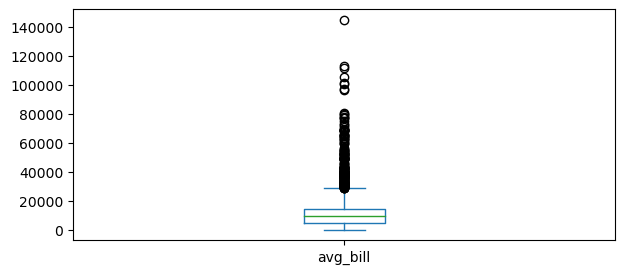

In [ ]:
# matplotlib 활용하여 박스 플랏 시각화
# 박스 플랏 그래프를 보니 , 굉장히 큰값들이 존재하는걸로 보입니다. 

import matplotlib.pyplot as plt

plt.figure(figsize=(7,3))
cust['avg_bill'].plot(kind='box')
plt.show()

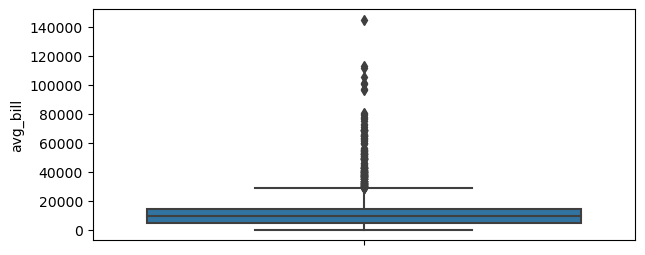

In [ ]:
# seaborn 활용하여 박스 플랏 시각화
# 박스 플랏 그래프를 보니 , 굉장히 큰값들이 존재하는걸로 보입니다. 

import seaborn as sns

plt.figure(figsize=(7,3))
sns.boxplot(data=cust, y='avg_bill')
plt.show()

<br>

### **연속형 데이터에 대한 IQR 계산해서 이상치 확인하기**     
Q1와 Q3가 거리의 1.5배가 넘어가는 값을 Outlier 라고 합니다. 즉,       
Q3 - Q1 = IQR   
Q1 - 1.5 * IQR (Lower Fence)보다 작은 값들과 Q3 + 1.5 * IQR (Upper Fence)보다 큰 값들을 이상치(Outlier)라고 합니다.   
이 값들은 이상치로써 제거 또는 변경하여 데이터를 분석,학습 할수 있으나,    
때에 따라서는 이상치라고 해서 제거나 변경하지 않고 진행하는 경우도 많습니다.    
도메인전문가와 협의해서 이상치와 처리여부에 대해 협의하시기 바랍니다.  

In [ ]:
# 위의 공식을 적용하여 이상치 데이터만 제거하는 함수 만들어 보겠습니다.

def removeOutliers(df, column):
    
    # Q1, Q3구하기
    q1 = df[column].quantile(0.25) # 1사분위값
    q3 = df[column].quantile(0.75) # 3사분위값
    
    # 1.5 * IQR(Q3 - Q1)
    iqr = 1.5 * (q3 - q1)
    
    # 이상치를 제거하고 이상치가 아닌 정상인 값들만 리턴함
    y = df[ ( df[ column ] < (q3 + iqr) ) & ( df[ column ] > (q1 - iqr) ) ]
    
    return(y)

In [ ]:
# 위의 removeOutliers 함수를 활용해서 'avg_bill' 연속형 컬럼에 대해 이상치 제거해 보겠습니다. 
cust = removeOutliers(cust, 'avg_bill')

In [ ]:
# avg_bill 컬럼에 대한 이상치를 제거후 avg_bill 컬럼에 대한 전후 통계 비교해 보겠습니다.
# 이상치 제거전 :  avg_bill 컬럼의 최대값 144,739
# 이상치 제거후 : avg_bill 컬럼의  최대값 28,649 --> 최대값의 변경 있음!!

cust.describe()

,age,service,avg_bill,A_bill,B_bill
count,8066.00,8066.00,8066.00,8066.00,8066.00
mean,48.08,1.22,9583.54,1652.91,5474.78
std,19.30,0.79,5823.99,1590.70,4086.68
min,4.00,0.00,299.90,0.00,0.00
25%,33.00,1.00,4649.19,358.65,2302.00
50%,49.00,1.00,9199.10,1654.06,5305.61
75%,62.00,1.00,14001.67,2296.35,8281.07
max,104.00,14.00,28649.30,19698.53,19965.38


In [ ]:
# 동일한 함수로 나머지 연속형 변수에 대해서도 이상치를 제거해 보겠습니다.
# A_bill : 이상치 제거전 최대값 131,581 , 이상치 제거후 최대값 5,190
# B_bill : 이상치 제거전 최대값 658,36 , 이상치 제거후 최대값 17,034
# 자주 사용하는 코딩에 대해 함수로 만들어 사용하시면 반복 수작업을 제거할수 있습니다.
# removeOutliers 함수를 여러번 수행하게 되면, 계속해서 outlier 이상치를 삭제하게 되어 통계 수치가 변경됩니다. 

cust=removeOutliers(cust, 'A_bill')
cust=removeOutliers(cust, 'B_bill')
cust.describe()

,age,service,avg_bill,A_bill,B_bill
count,7814.00,7814.00,7814.00,7814.00,7814.00
mean,48.08,1.19,9386.91,1483.58,5440.97
std,19.38,0.72,5724.55,1091.18,3970.95
min,4.00,0.00,299.90,0.00,0.00
25%,33.00,1.00,4435.20,342.00,2384.75
50%,49.00,1.00,9028.10,1615.87,5308.10
75%,62.00,1.00,13766.82,2238.00,8204.87
max,104.00,9.00,28649.30,5190.53,17034.60


In [ ]:
# 연속형 변수에 대해서 이상치를 제거하니, 전체건수가 8,228 --> 7,814건으로 줄어 들었습니다. 
cust.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7814 entries, 0 to 8227
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   class        7814 non-null   object 
 1   sex          7814 non-null   object 
 2   age          7814 non-null   float64
 3   service      7814 non-null   int64  
 4   stop         7814 non-null   object 
 5   npay         7814 non-null   object 
 6   avg_bill     7814 non-null   float64
 7   A_bill       7814 non-null   float64
 8   B_bill       7814 non-null   float64
 9   termination  7814 non-null   object 
dtypes: float64(4), int64(1), object(5)
memory usage: 671.5+ KB


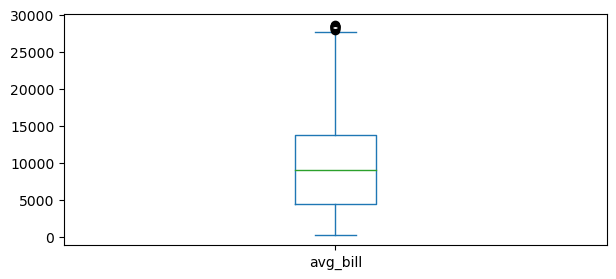

In [ ]:
# matplotlib 활용하여 박스 플랏 시각화
# 박스 플랏 그래프를 보니 , 이상치 제거된걸 확인할수 있습니다. 

import matplotlib.pyplot as plt

plt.figure(figsize=(7,3))
cust['avg_bill'].plot(kind='box')
plt.show()

<br>

## **2. Feature Engineering**
모델 정확도를 높이기 위해서 주어진 데이터를 잘 표현할 수 있는 features로 변형시키는 과정이며   
데이터의 도메인 지식을 활용해 feature를 만드는 과정입니다.    

In [ ]:
# 퓨쳐 엔지니어링을 하기전에 다시 cust 데이터프레임을 확인해 봅시다.
cust.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.00,0,N,N,2640.00,792.00,1584.00,Y
1,E,F,24.00,1,N,N,16840.00,2526.00,6983.00,N
2,F,F,32.00,1,N,N,15544.73,2331.71,6750.47,N
3,D,M,18.00,1,N,N,4700.00,0.00,4502.00,N
4,C,F,78.00,1,N,N,1361.80,1174.00,0.00,N


<br>

### <b>Binning</b>
Binning은 단어 뜻 그대로 자료를 일정한 규격의 통에 넣는것 입니다.    
연속형 데이터를 범위(구간)를 나누어 범주형 데이터로 만든다고 생각하시면 됩니다.  
이렇게 해서 연속형 데이터를 구간별로 나눠 범주형 데이터를 새로 만들수 있습니다.    
이게 바로 Feature Engineering 예제입니다.

In [ ]:
# Feature Engineering 예제로 
# age 컬럼을 활용하여 나이대("by_age") 컬럼을 새로 만들어 보겠습니다. 
# 나이 값 // 10 하면 몫만 나오게 되며 거기에 곱하기 10을 하면 10, 20, 30 처럼 나오게 됩니다.

cust[ 'by_age' ] = cust[ 'age' ] // 10 * 10

In [ ]:
# 새로운 'by_age' 컬럼이 생성되었으며, 기존 age 컬럼의 값을 10, 20, 30 대로 범주형 컬럼으로 변경했습니다.
# 이렇듯이 기존 데이터를 가지고 새로운 컬럼을 만들어 내는것이 feature engineering의 예 입니다. 

cust.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination,by_age
0,C,F,28.00,0,N,N,2640.00,792.00,1584.00,Y,20.00
1,E,F,24.00,1,N,N,16840.00,2526.00,6983.00,N,20.00
2,F,F,32.00,1,N,N,15544.73,2331.71,6750.47,N,30.00
3,D,M,18.00,1,N,N,4700.00,0.00,4502.00,N,10.00
4,C,F,78.00,1,N,N,1361.80,1174.00,0.00,N,70.00


<br>

<br>

### <b>Label Encording

컴퓨터는 숫자를 잘 이해하고 계산을 잘 합니다.   
하지만, 문자열 데이터의 경우, 이해하지 못하기에 문자열 데이터를 숫자로 표현해 주어야 합니다.   
예를 들어, 성별 (sex) 컬럼의 값이 M 과 F 가 있으며, 컴퓨터가 이해할수 있게     
여자 F는 0 으로, 남자 M은 1로 이런식으로 숫자로 매핑해 주어야 합니다.   
이렇게 범주형 컬럼의 값들을 숫자로 매핑해 주는 방법이 라벨 인코딩(Label Encording) 입니다.  

In [ ]:
# 문자열 컬럼 : class, sex, stop, npay, termination 
# 모델이 문자열 컬럼을 잘 이해할수 있도록 숫자형태로 변경 필요.

cust.head(3)

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination,by_age
0,C,F,28.00,0,N,N,2640.00,792.00,1584.00,Y,20.00
1,E,F,24.00,1,N,N,16840.00,2526.00,6983.00,N,20.00
2,F,F,32.00,1,N,N,15544.73,2331.71,6750.47,N,30.00
3,D,M,18.00,1,N,N,4700.00,0.00,4502.00,N,10.00
4,C,F,78.00,1,N,N,1361.80,1174.00,0.00,N,70.00
...,...,...,...,...,...,...,...,...,...,...,...
8223,C,M,76.00,1,N,N,1860.00,1716.00,0.00,N,70.00
8224,C,F,15.00,1,N,Y,1296.10,194.41,643.10,N,10.00
8225,G,M,12.00,1,N,N,13799.67,2069.95,10605.93,N,10.00
8226,C,F,40.00,0,N,N,3140.00,942.00,1884.00,Y,40.00


In [ ]:
# 여러가지 방법으로 성별 컬럼의 값들을 숫자로 변경 가능합니다. 
# 첫번째 방법 : replace 함수 사용하여 F는 0으로 , M은 1로 매핑합니다. 

cust[ 'sex' ].replace( {'F' : 0, 'M':1 } ).head()

0    0
1    0
2    0
3    1
4    0
Name: sex, dtype: int64

In [ ]:
# 두번째 방법 : 사이킷런의 LabelEncoder 함수를 사용합니다. 
# 라벨인코더(LabelEncoder) 임포트하고 정의하고 변환하여 문자열을 숫자로 매핑하게 됩니다. 

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cust[ 'sex' ] = le.fit_transform(cust[ 'sex' ])
cust.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination,by_age
0,C,0,28.00,0,N,N,2640.00,792.00,1584.00,Y,20.00
1,E,0,24.00,1,N,N,16840.00,2526.00,6983.00,N,20.00
2,F,0,32.00,1,N,N,15544.73,2331.71,6750.47,N,30.00
3,D,1,18.00,1,N,N,4700.00,0.00,4502.00,N,10.00
4,C,0,78.00,1,N,N,1361.80,1174.00,0.00,N,70.00


<br>

### <b>One-Hot Encording

학점 A/B/C/D/F 처럼 순서가 있는 문자열 컬럼의 값들을 라벨인코딩을 통해 숫자로 매핑할수 있습니다.  
이럴경우, 어떤 문자열은 숫자가 작고 , 어떤 문자열은 숫자가 높게 되어 , 모델이 잘못 이해할수도 있게 됩니다.   
이런 문제점을 해결하기 위해 문자열이 숫자로 매핑될때, 똑같은 입장에서 바라볼수 있도록 해 주는것이 원핫 인코딩입니다.    

아래 예시와 같이 'color' 컬럼에는 3개의 문자열 red, green, blue 구성되었을 경우,    
3개의 red, green, blue 값들은 순서가 없으며, 컴퓨터가 이해할수 있도록 해야 되는데,     
이때 원핫 인코딩(One-Hot Encording)으로 표현하여 아래와 같이 red는 1 0 0 , green는 0 1 0 , blue는 0 0 1로 표현하게 됩니다. 

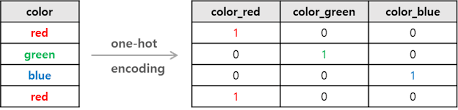

In [ ]:
# 위에서 사용한 cust_data_obj 데이터프레임의 내용을 확인해 보겠습니다.
# 성별 컬럼은 라벨인코딩으로 숫자로 매핑 완료 되었으며
# 등급 컬럼은 아직도 문자열로 보여지고 있습니다. 

cust.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination,by_age
0,C,0,28.00,0,N,N,2640.00,792.00,1584.00,Y,20.00
1,E,0,24.00,1,N,N,16840.00,2526.00,6983.00,N,20.00
2,F,0,32.00,1,N,N,15544.73,2331.71,6750.47,N,30.00
3,D,1,18.00,1,N,N,4700.00,0.00,4502.00,N,10.00
4,C,0,78.00,1,N,N,1361.80,1174.00,0.00,N,70.00


In [ ]:
# pandas에서는 get_dummies함수를 사용하면 쉽게 One-Hot Encording이 가능합니다.
# get_dummies함수를 이용해서 cust_data_obj 데이터프레임의 class 등급 컬럼에 대해서 원핫인코딩을 수행해 보겠습니다.
# 원핫인코딩 결과를 보니, 1개의 등급 컬럼이 5개의 범주 컬럼으로 변환 되었습니다. 
# 5개의 컬럼중에 1개만 1이고, 나머지 0으로 나오게 됩니다. 이게 바로 원핫인코딩 적용 결과입니다.

pd.get_dummies( data=cust, columns=[ 'class' ] ).head()

,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination,by_age,class_C,class_D,class_E,class_F,class_G,class_H
0,0,28.00,0,N,N,2640.00,792.00,1584.00,Y,20.00,True,False,False,False,False,False
1,0,24.00,1,N,N,16840.00,2526.00,6983.00,N,20.00,False,False,True,False,False,False
2,0,32.00,1,N,N,15544.73,2331.71,6750.47,N,30.00,False,False,False,True,False,False
3,1,18.00,1,N,N,4700.00,0.00,4502.00,N,10.00,False,True,False,False,False,False
4,0,78.00,1,N,N,1361.80,1174.00,0.00,N,70.00,True,False,False,False,False,False


<br>

<br>

# **[실습] 수업용 데이터에 대해 전처리 하기**

- 'npay' 컬럼을 사이킷런의 LabelEncoder 함수를 사용해서 라벨인코딩 수행하세요.
- 'termination' 컬럼을 판다스의 get_dummies 함수를 활용해서 더미화 하세요. (drop_first=True 옵션 사용)
- cust 데이터프레임에 결측치가 있는지 확인해 보세요.

In [ ]:
# 기존에 복사해둔 cust_fix 데이터프레임을 복사합니다. 
cust = cust_fix.copy()

In [ ]:
# cust 데이터프레임 내용을 확인해 봅니다.
# 결측치 값들이 보입니다.

cust.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.00,0,N,N,2640.00,792.00,1584.00,Y
1,E,F,24.00,1,N,N,16840.00,2526.00,6983.00,N
2,F,F,32.00,1,N,N,15544.73,2331.71,6750.47,N
3,D,M,18.00,1,N,N,4700.00,0.00,4502.00,N
4,C,F,78.00,1,N,N,1361.80,1174.00,0.00,N


In [ ]:
# 'npay' 컬럼을 사이킷런의 LabelEncoder 함수를 사용해서 라벨인코딩 수행하세요.

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cust[ 'npay' ] = le.fit_transform(cust[ 'npay' ])
cust

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.00,0,N,0,2640.00,792.00,1584.00,Y
1,E,F,24.00,1,N,0,16840.00,2526.00,6983.00,N
2,F,F,32.00,1,N,0,15544.73,2331.71,6750.47,N
3,D,M,18.00,1,N,0,4700.00,0.00,4502.00,N
4,C,F,78.00,1,N,0,1361.80,1174.00,0.00,N
...,...,...,...,...,...,...,...,...,...,...
8223,C,M,76.00,1,N,0,1860.00,1716.00,0.00,N
8224,C,F,15.00,1,N,1,1296.10,194.41,643.10,N
8225,G,M,12.00,1,N,0,13799.67,2069.95,10605.93,N
8226,C,F,40.00,0,N,0,3140.00,942.00,1884.00,Y


In [ ]:
# 'termination' 컬럼을 판다스의 get_dummies 함수를 활용해서 더미화 하세요. 
# drop_first=True 옵션 사용하지 않았으며, 
# termination 컬럼이 termination_N, termination_Y 2개로 원핫인코딩 확인할수 있음.
# 판다스 버젼업이 되면서 0, 1로 표시 안되고 True, False 표기되어 dtype='int' 사용함.

pd.get_dummies( data=cust, columns=[ 'termination' ] , dtype='int')

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination_N,termination_Y
0,C,F,28.00,0,N,N,2640.00,792.00,1584.00,0,1
1,E,F,24.00,1,N,N,16840.00,2526.00,6983.00,1,0
2,F,F,32.00,1,N,N,15544.73,2331.71,6750.47,1,0
3,D,M,18.00,1,N,N,4700.00,0.00,4502.00,1,0
4,C,F,78.00,1,N,N,1361.80,1174.00,0.00,1,0
...,...,...,...,...,...,...,...,...,...,...,...
8223,C,M,76.00,1,N,N,1860.00,1716.00,0.00,1,0
8224,C,F,15.00,1,N,Y,1296.10,194.41,643.10,1,0
8225,G,M,12.00,1,N,N,13799.67,2069.95,10605.93,1,0
8226,C,F,40.00,0,N,N,3140.00,942.00,1884.00,0,1


In [ ]:
# 'termination' 컬럼을 판다스의 get_dummies 함수를 활용해서 더미화 하세요. (drop_first=True 옵션 사용)
# termination 컬럼이 termination_N, termination_Y 2개로 원핫인코딩 되지만
# drop_first=True 옵션 사용으로 첫번째 생성된 termination_N 컬럼이 삭제되어 termination_Y 컬럼만 남음.

cust = pd.get_dummies( data=cust, columns=[ 'termination' ], drop_first=True, )
cust.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination_Y
0,C,F,28.00,0,N,N,2640.00,792.00,1584.00,True
1,E,F,24.00,1,N,N,16840.00,2526.00,6983.00,False
2,F,F,32.00,1,N,N,15544.73,2331.71,6750.47,False
3,D,M,18.00,1,N,N,4700.00,0.00,4502.00,False
4,C,F,78.00,1,N,N,1361.80,1174.00,0.00,False


In [ ]:
# cust 데이터프레임에 결측치가 있는지 확인해 보세요.
cust.isna().sum()

class            0
sex              0
age              0
service          0
stop             0
npay             0
avg_bill         0
A_bill           0
B_bill           0
termination_Y    0
dtype: int64

# **정리**
배운 내용을 정리해 보겠습니다. 
- DataFrame은 2차원(col과 row을 가짐)테이블 데이터 구조를 가지는 자료형으로
- DataFrame 생성 : read_csv()
- DataFrame 내용 확인 : head(), tail(), info(), shape, columns, index, values, descrbe()
- DataFrame 조회하기 : loc, iloc 
- DataFrame  boolean indexing으로 원하는 row 선택하기
- DataFrame  추가, 삭제하기(drop)
- 결측치 : Missing Value로 데이터에 값이 없는 것을 의미. NA, Null, NaN으로 표시
- 결측치 처리하기 : isnull(), fillna(), dropna()
- 이상치는 특정 추세에서 크게 벗어난 데이터 혹은 중앙값을 크게 벗어난 데이터를 의미하며
- value_counts 함수나, boxplot 그래프를 활용하여 이상치 파악후 이상치 삭제나 대체하는 방법을 사용합니다.
- Feature Engineering은 모델 정확도를 높이기 위해서 주어진 데이터를 잘 표현할 수 있는 features로 변형시키는 과정이며 데이터의 도메인 지식을 활용해 feature를 만드는 과정입니다.
- Feature Engineering 하는 방법에는 bining 구간화을 실습해 보았습니다.